# One network, two ways of calculating: **node view** vs **link view**

**Data:** your own ERA5 daily maximum temperature, South Asia (5–45°N, 55–105°E), March–September 2000–2025
(`Dataset Real/Tmax/`). Nothing synthetic: every node, link and number below comes from that data.

**The single idea of this notebook**

A network is a table of relationships: a square matrix $A$ where $A_{ij}=1$ if place $i$ and place $j$ are linked.
You can compute on it in two fundamentally different ways:

| | **Node view** | **Link view** |
|---|---|---|
| unit of analysis | a place (one row of $A$) | a relationship (one cell of $A$) |
| typical operation | *summarise* the row: count, sum, average | *keep* each cell as an object with its own properties |
| examples | degree, strength, clustering, betweenness, node communities | link length, link direction, edge betweenness, link communities, bundle support |
| what it answers | "How important / connected is this place?" | "Which relationships exist, how far, which way, how trustworthy?" |
| what it throws away | **where** the links go | nothing about pairs, but every single link is a noisy statistical test |

The notebook builds **one** heatwave synchronisation network and then analyses it both ways, so every difference you
see is caused by the *way of calculating*, never by the data.

**Pipeline**
```
ERA5 daily Tmax (0.5°, Mar–Sep 2000–2025)
   │  coarsen to 2° blocks, keep land, remove each node's linear warming trend
   ▼
Heatwave ONSETS per node      (Tmax > local 90th percentile, ±7-day window, ≥ 3 consecutive days)
   │
   ▼
Event synchronisation for every pair of nodes  →  Q (how often onsets coincide), q (who goes first)
   │  null model: shuffle years 2000× → p-value per pair → false-discovery-rate 5 %
   ▼
ONE network  (nodes = 2° land cells, links = significant synchronisation)
   ├───────── PART 3: NODE VIEW ─────────┐      ┌──────── PART 4: LINK VIEW ─────────┐
   │ degree · strength · clustering      │      │ length · direction · edge betweenness│
   │ betweenness · node communities      │      │ link communities · bundle support    │
   └─────────────────┬───────────────────┘      └─────────────────┬──────────────────┘
                     └────────── PART 5: HEAD-TO-HEAD ─────────────┘
          same degree, different story · boundaries vs overlap · robustness to noise & to the null model
```

**Parts:** 0 toy example · 1 data → events · 2 events → links · 3 node view · 4 link view · 5 head-to-head · 6 summary & data list.

In [1]:
from pathlib import Path
import glob, itertools, random, warnings
import numpy as np, pandas as pd, xarray as xr
import igraph as ig
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import cartopy.crs as ccrs, cartopy.feature as cfeature
from numba import njit, prange
from scipy.stats import spearmanr
from sklearn.metrics import normalized_mutual_info_score as nmi
warnings.filterwarnings("ignore", category=RuntimeWarning)

BASE_DIR = Path("/Users/samirafarzana/Documents/Domain Expansion  Heatwave Analysis")
OUT_DIR  = BASE_DIR / "Node vs Link Network"
FIG_DIR  = OUT_DIR / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── pipeline parameters: change here, everything downstream follows ──────────
COARSEN   = 4        # 4×4 blocks of 0.5° cells → 2° nodes
LAND_FRAC = 0.5      # a 2° block is a node if ≥ 50 % of it is land
PCTL      = 90       # heatwave threshold percentile (p95 leaves only ~30 events per node at 2°: too few per link)
WIN_HALF  = 7        # ±7 days → 15-day calendar window for the threshold (same as NPipeline)
MIN_DUR   = 3        # a heatwave lasts ≥ 3 consecutive days
TAU_MAX   = 5.0      # max synchronisation lag in days (same convention as NPipeline)
N_SURR    = 2000     # surrogates per pair for the null model
FDR_Q     = 0.05     # Benjamini–Hochberg false discovery rate
LONG_KM   = 2000     # links longer than this are called "long" (candidate teleconnections)
BUNDLE_R  = 450      # km: neighbourhood radius used for bundle support
SEED      = 42
rng = np.random.default_rng(SEED)

In [2]:
# ── plotting style: one system for every figure ─────────────────────────────
INK, INK2, MUTED, GRIDC, AXISC, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, ORANGE = "#2a78d6", "#eb6834"                 # categorical slots 1, 2
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]   # slots 1–5, fixed order (lines)
CAT5   = ["#2a78d6", "#1baf7a", "#eda100", "#4a3aa7", "#e34948"]   # map palette, validated all-pairs; used WITH number labels
BLUE_RAMP = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7", "#3987e5",
             "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]
SEQ = LinearSegmentedColormap.from_list("seq_blue", BLUE_RAMP)
DIV = LinearSegmentedColormap.from_list("div_blue_red", ["#184f95", "#6da7ec", "#f0efec", "#ec8b8a", "#b3282b"])

mpl.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "font.family": ["Helvetica Neue", "DejaVu Sans"],      # DejaVu fills glyphs Helvetica lacks (→)
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": AXISC, "axes.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRIDC, "grid.linewidth": 0.5, "legend.frameon": False,
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
})
PC = ccrs.PlateCarree()
EXTENT = [55, 105, 5, 45]

def base_map(ax, title=None):
    ax.set_extent(EXTENT, PC)
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), lw=0.45, edgecolor=MUTED)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), lw=0.3, edgecolor=AXISC)
    ax.spines["geo"].set_edgecolor(AXISC); ax.spines["geo"].set_linewidth(0.6)
    if title: ax.set_title(title)
    return ax

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png"); plt.show()

---
## Part 0 — The idea on a 9-node toy network

Two tight friend groups, {0,1,2,3,4} and {4,5,6,7,8}, that share one person: node 4.

* **Node view (Louvain communities on nodes):** every *node* gets exactly one label, so node 4 has to pick a side.
* **Link view (the same Louvain algorithm, run on *links*):** every *link* gets exactly one label. Node 4 has 4 links into
  each group, so it ends up in **both** communities. This is overlap, and you can only get it by calculating on links.

How do you run a community algorithm on links? Turn the network inside-out into its **line graph**:
every link becomes a dot, and two dots are joined if the two links share an endpoint. The joining weight is the
Ahn–Bagrow–Lehmann (2010) link similarity: for links $(i,k)$ and $(j,k)$ that share node $k$,

$$ S\big((i,k),(j,k)\big) = \frac{|N^+(i)\cap N^+(j)|}{|N^+(i)\cup N^+(j)|} $$

where $N^+(i)$ is node $i$ together with its neighbours. In words: two links are similar if their *other* ends have the
same friends. Clustering the line graph with Louvain is the Evans & Lambiotte (2009) approach. The functions below are the
exact ones used later on the real heatwave network.

In [3]:
def best_louvain(g, weights=None, n_runs=20, seed=SEED):
    """Louvain is randomised: run it n_runs times and keep the partition with the highest modularity."""
    best = None
    for r in range(n_runs):
        random.seed(seed + r)                       # python-igraph draws its randomness from Python's `random`
        part = g.community_multilevel(weights=weights)
        if best is None or part.modularity > best.modularity:
            best = part
    return np.array(best.membership), best.modularity

def line_graph(A):
    """Turn every link of A into a node of a new graph (the line graph).
    Returns: the link list `ei` (E×2) and the line-graph edges (l1, l2) with Ahn similarity weights `w`."""
    N = len(A)
    ei = np.array(np.where(np.triu(A, 1))).T                      # every link (i<j) once
    B = (A | np.eye(N, dtype=bool)).astype(np.int32)              # N+(i): neighbours plus i itself
    inter = B @ B                                                 # |N+(i) ∩ N+(j)|
    size = B.sum(1)
    J = inter / (size[:, None] + size[None, :] - inter)           # Jaccard of N+ sets
    eid = -np.ones((N, N), np.int64)
    eid[ei[:, 0], ei[:, 1]] = eid[ei[:, 1], ei[:, 0]] = np.arange(len(ei))
    l1, l2, w = [], [], []
    for k in range(N):                                            # links (k,i) and (k,j) touch at k
        nb = np.where(A[k])[0]
        if len(nb) < 2:
            continue
        a, b = np.triu_indices(len(nb), 1)
        l1.append(eid[k, nb[a]]); l2.append(eid[k, nb[b]]); w.append(J[nb[a], nb[b]])
    return ei, np.concatenate(l1), np.concatenate(l2), np.concatenate(w)

def link_communities(A, n_runs=20):
    """Louvain on the weighted line graph → one community label per LINK."""
    ei, l1, l2, w = line_graph(A)
    L = ig.Graph(n=len(ei), edges=np.c_[l1, l2].tolist())
    lab, Qmod = best_louvain(L, weights=w, n_runs=n_runs)
    return ei, lab, Qmod

def node_memberships(ei, lab, N):
    """For each node: the share of its links that fall in each link community (rows sum to 1)."""
    F = np.zeros((N, lab.max() + 1))
    np.add.at(F, (ei[:, 0], lab), 1); np.add.at(F, (ei[:, 1], lab), 1)
    return F / F.sum(1, keepdims=True)

node view : node 4 degree = 8 | node community of node 4 = 0 | communities: [[0, 1, 2, 3, 4], [5, 6, 7, 8]]
link view : share of node 4's links in each link community = [0.5 0.5]


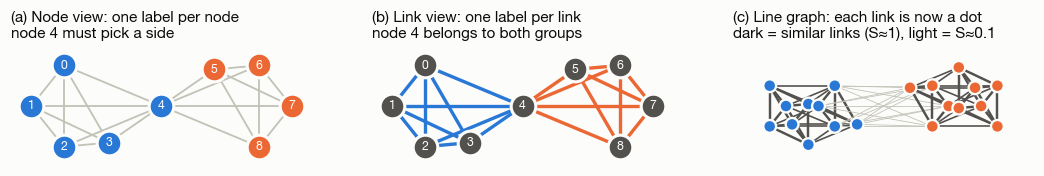

In [4]:
groups = ([0, 1, 2, 3, 4], [4, 5, 6, 7, 8])
toy_edges = [e for grp in groups for e in itertools.combinations(grp, 2)]
A_toy = np.zeros((9, 9), bool)
for a, b in toy_edges:
    A_toy[a, b] = A_toy[b, a] = True
pos = np.array([[-2.4, 1.0], [-3.2, 0.0], [-2.4, -1.0], [-1.3, -0.9], [0.0, 0.0],
                [1.3, 0.9], [2.4, 1.0], [3.2, 0.0], [2.4, -1.0]])

g_toy = ig.Graph(n=9, edges=np.array(np.where(np.triu(A_toy, 1))).T.tolist())
toy_node_lab, _ = best_louvain(g_toy)
toy_ei, toy_link_lab, _ = link_communities(A_toy)
toy_F = node_memberships(toy_ei, toy_link_lab, 9)
print("node view : node 4 degree =", A_toy[4].sum(), "| node community of node 4 =", toy_node_lab[4],
      "| communities:", [list(np.where(toy_node_lab == c)[0]) for c in np.unique(toy_node_lab)])
print("link view : share of node 4's links in each link community =", np.round(toy_F[4], 2))

fig, axs = plt.subplots(1, 3, figsize=(12, 3.6))
C2 = [BLUE, ORANGE]
for ax in axs:
    ax.set_aspect("equal"); ax.axis("off"); ax.set_xlim(-3.7, 3.7); ax.set_ylim(-1.45, 1.45)
# (a) node view
ax = axs[0]
for a, b in toy_ei:
    ax.plot(*pos[[a, b]].T, color=AXISC, lw=1.2, zorder=1)
for n in range(9):
    ax.scatter(*pos[n], s=260, color=C2[toy_node_lab[n]], edgecolor=SURF, lw=2, zorder=2)
    ax.text(*pos[n], str(n), ha="center", va="center", color="white", fontsize=8, fontweight="bold", zorder=3)
ax.set_title("(a) Node view: one label per node\nnode 4 must pick a side")
# (b) link view
ax = axs[1]
for (a, b), c in zip(toy_ei, toy_link_lab):
    ax.plot(*pos[[a, b]].T, color=C2[c], lw=2.2, zorder=1)
for n in range(9):
    ax.scatter(*pos[n], s=260, color=INK2, edgecolor=SURF, lw=2, zorder=2)
    ax.text(*pos[n], str(n), ha="center", va="center", color="white", fontsize=8, fontweight="bold", zorder=3)
ax.set_title("(b) Link view: one label per link\nnode 4 belongs to both groups")
# (c) line graph
ax = axs[2]
_, l1, l2, w = line_graph(A_toy)
mid = pos[toy_ei].mean(1)
for a, b, s in zip(l1, l2, w):
    ax.plot(*mid[[a, b]].T, color=INK2 if s > 0.5 else AXISC, lw=0.4 + 1.2 * s, zorder=1)
ax.scatter(*mid.T, s=70, c=[C2[c] for c in toy_link_lab], edgecolor=SURF, lw=1.5, zorder=2)
ax.set_title("(c) Line graph: each link is now a dot\ndark = similar links (S≈1), light = S≈0.1")
save(fig, "fig00_toy_node_vs_link")

**What this shows.** The node view gives node 4 one label (community 0). Nothing in that output reveals that node 4 is
just as much part of {5,6,7,8}. The link view splits node 4's 8 links 4 + 4 between two link communities, so node 4 is
a member of **both**, 50/50. In the line graph (c), links that meet at node 4 but lead into different groups are joined
only weakly (S = 1/9 ≈ 0.11, light grey), so Louvain cuts there. Everything below is this same contrast, on 336 real places.

---
## Part 1 — Data → heatwave events

**Steps**
1. Load all 182 monthly ERA5 `t2m` (daily maximum) files and convert K → °C.
2. **Coarsen to 2°** (mean of 4×4 blocks of 0.5° cells). This gives a few hundred nodes, enough to be realistic and still
   small enough to draw every link and run thousands of surrogates. Keep blocks that are ≥ 50 % land.
3. **Remove each node's linear trend.** Otherwise later years have more "heatwaves" everywhere at once, and the network
   would link places just for sharing the warming trend.
4. **Heatwave** = Tmax above that node's own 90th percentile for that time of year (15-day calendar window) on
   ≥ 3 consecutive days. The **event** used for synchronisation is the **onset day** (the first day) of each heatwave.

In [5]:
files = sorted(glob.glob(str(BASE_DIR / "Dataset Real/Tmax/tmax_*.nc")))
tmax = xr.concat([xr.open_dataset(f)["t2m"].load() for f in files], "valid_time")
tmax = (tmax.rename(valid_time="time", latitude="lat", longitude="lon")
            .drop_vars("number", errors="ignore").sortby("lat") - 273.15)
land = xr.open_dataset(BASE_DIR / "From Scratch/land_mask.nc")["land_mask"].sortby("lat")
print(f"{len(files)} files | {tmax.sizes['time']} days | grid {tmax.sizes['lat']}×{tmax.sizes['lon']} at 0.5°")

t2 = tmax.coarsen(lat=COARSEN, lon=COARSEN, boundary="trim").mean()
lf = land.astype(float).coarsen(lat=COARSEN, lon=COARSEN, boundary="trim").mean()
assert np.allclose(t2.lat, lf.lat) and np.allclose(t2.lon, lf.lon)
lat_c, lon_c = t2.lat.values, t2.lon.values                     # 2° grid centres
is_land = (lf.values >= LAND_FRAC)
ilat, ilon = np.where(is_land)                                  # grid position of every node
lat, lon = lat_c[ilat], lon_c[ilon]
X = t2.values[:, ilat, ilon]                                    # (time, node) in °C
dates = pd.DatetimeIndex(t2.time.values)
N = X.shape[1]
print(f"2° grid {len(lat_c)}×{len(lon_c)} → {N} land nodes")

# remove each node's linear trend (keeps the mean, removes the slope)
t_years = ((dates - dates[0]).days.values / 365.25)
slope = np.polyfit(t_years, X, 1)[0]
Xd = X - np.outer(t_years - t_years.mean(), slope)
print(f"Tmax trend: median {10*np.median(slope):.2f} °C/decade (5–95 %: {10*np.percentile(slope,5):.2f} to {10*np.percentile(slope,95):.2f})")

182 files | 5564 days | grid 81×101 at 0.5°


2° grid 20×25 → 336 land nodes
Tmax trend: median 0.55 °C/decade (5–95 %: -0.16 to 0.89)


In [6]:
# local, calendar-aware threshold: for each day-of-year, the 90th percentile of all days within ±7 days
doy = dates.dayofyear.values
thr = np.full((367, N), np.nan)
for d in np.unique(doy):
    window = np.abs(((doy - d + 183) % 366) - 183) <= WIN_HALF
    thr[d] = np.percentile(Xd[window], PCTL, axis=0)
hot = Xd > thr[doy]

dayno = (dates - dates[0]).days.values          # continuous day number (gaps Oct–Feb are real gaps)
def heatwaves(h):
    """Runs of ≥ MIN_DUR hot days that are also consecutive calendar days. Returns (onset index, length) pairs."""
    out, k, T = [], 0, len(h)
    while k < T:
        if h[k]:
            j = k
            while j + 1 < T and h[j + 1] and dayno[j + 1] == dayno[j] + 1:
                j += 1
            if j - k + 1 >= MIN_DUR:
                out.append((k, j - k + 1))
            k = j + 1
        else:
            k += 1
    return out

hw_day = np.zeros_like(hot)
onsets = []                                      # onsets[n] = day numbers of heatwave onsets at node n
for n in range(N):
    runs = heatwaves(hot[:, n])
    for k, L in runs:
        hw_day[k:k + L, n] = True
    onsets.append(np.array([dayno[k] for k, _ in runs]))
n_ev = np.array([len(e) for e in onsets])
print(f"heatwave onsets per node: min {n_ev.min()}, median {np.median(n_ev):.0f}, max {n_ev.max()}  (26 seasons)")

heatwave onsets per node: min 45, median 67, max 90  (26 seasons)


In [7]:
CITIES = {"Delhi": (28.6, 77.2), "Lahore": (31.5, 74.3), "Karachi": (24.9, 67.0), "Mumbai": (19.1, 72.9),
          "Kolkata": (22.6, 88.4), "Dhaka": (23.8, 90.4), "Kathmandu": (27.7, 85.3), "Lhasa": (29.7, 91.1),
          "Kabul": (34.5, 69.2), "Tashkent": (41.3, 69.2), "Almaty": (43.2, 76.9), "Urumqi": (43.8, 87.6),
          "Chengdu": (30.7, 104.1), "Kunming": (25.0, 102.7), "Yangon": (16.8, 96.2), "Bangkok": (13.8, 100.5),
          "Hyderabad": (17.4, 78.5), "Chennai": (13.1, 80.3), "Ahmedabad": (23.0, 72.6), "Muscat": (23.6, 58.4),
          "Nagpur": (21.1, 79.1), "Patna": (25.6, 85.1), "Jaipur": (26.9, 75.8), "Multan": (30.2, 71.5),
          "Quetta": (30.2, 67.0), "Kashgar": (39.5, 76.0), "Lanzhou": (36.1, 103.8), "Ashgabat": (38.0, 58.4),
          "Mandalay": (22.0, 96.1), "Colombo": (6.9, 79.9), "Dushanbe": (38.6, 68.8), "Bengaluru": (13.0, 77.6),
          "Kandahar": (31.6, 65.7), "Xining": (36.6, 101.8), "Bhopal": (23.3, 77.4), "Mashhad": (36.3, 59.6)}

def gc_km(la1, lo1, la2, lo2):
    la1, lo1, la2, lo2 = map(np.radians, (la1, lo1, la2, lo2))
    c = np.sin(la1) * np.sin(la2) + np.cos(la1) * np.cos(la2) * np.cos(lo1 - lo2)
    return 6371.0 * np.arccos(np.clip(c, -1, 1))

D = gc_km(lat[:, None], lon[:, None], lat[None, :], lon[None, :])   # node-to-node distance, km

def node_of(city):
    la, lo = CITIES[city]
    return int(np.argmin(gc_km(lat, lon, la, lo)))

def place(n):
    names = list(CITIES)
    d = np.array([gc_km(lat[n], lon[n], *CITIES[c]) for c in names])
    k = int(np.argmin(d))
    return f"near {names[k]}" if d[k] < 300 else f"{lat[n]:.1f}°N {lon[n]:.1f}°E"

def to_grid(v):
    """Node values → 2D grid (NaN over sea) for pcolormesh."""
    G = np.full((len(lat_c), len(lon_c)), np.nan); G[ilat, ilon] = v; return G

lat_e = np.r_[lat_c - 1.0, lat_c[-1] + 1.0]; lon_e = np.r_[lon_c - 1.0, lon_c[-1] + 1.0]
def node_map(ax, v, cmap=SEQ, norm=None, label="", vmin=None, vmax=None, cbar=True):
    m = ax.pcolormesh(lon_e, lat_e, to_grid(v), cmap=cmap, norm=norm, vmin=vmin, vmax=vmax,
                      transform=PC, edgecolor=SURF, linewidth=0.3)
    if cbar:
        cb = plt.colorbar(m, ax=ax, shrink=0.8, pad=0.02); cb.set_label(label); cb.outline.set_visible(False)
        if cbar == "space":              # keep panel widths aligned with neighbours that have a colour bar
            cb.ax.set_visible(False)
    return m

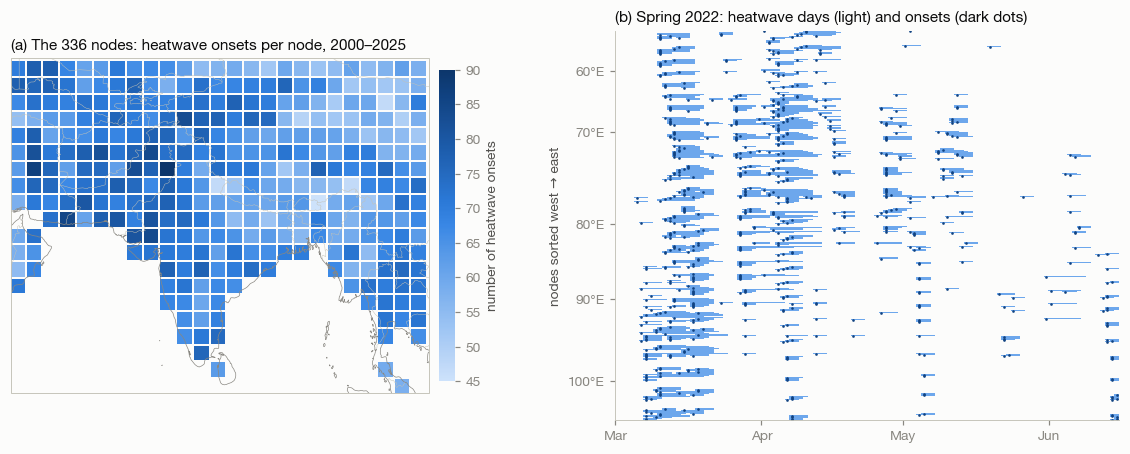

In [8]:
fig = plt.figure(figsize=(13, 4.6))
ax = base_map(fig.add_subplot(1, 2, 1, projection=PC), f"(a) The {N} nodes: heatwave onsets per node, 2000–2025")
node_map(ax, n_ev, label="number of heatwave onsets")

# (b) spring 2022: the record India–Pakistan heatwave season, nodes sorted west → east
ax = fig.add_subplot(1, 2, 2)
w = (dates >= "2022-03-01") & (dates <= "2022-06-15")
order = np.lexsort((lat, lon))                      # west → east
img = hw_day[w][:, order].T.astype(float)
ax.imshow(np.where(img > 0, 1, np.nan), aspect="auto", cmap=LinearSegmentedColormap.from_list("x", [BLUE_RAMP[4]] * 2),
          extent=[0, w.sum(), N, 0], interpolation="nearest")
on22 = [(np.searchsorted(dayno[w], e[(e >= dayno[w][0]) & (e <= dayno[w][-1])]), r) for r, e in enumerate(np.array(onsets, dtype=object)[order])]
for x, r in on22:
    ax.scatter(x + 0.5, np.full(len(x), r + 0.5), s=3, color=BLUE_RAMP[11], lw=0)
ticks = pd.date_range("2022-03-01", "2022-06-15", freq="MS")
ax.set_xticks([(t - pd.Timestamp("2022-03-01")).days for t in ticks]); ax.set_xticklabels([t.strftime("%b") for t in ticks])
yt = np.searchsorted(lon[order], [60, 70, 80, 90, 100]); ax.set_yticks(yt); ax.set_yticklabels(["60°E", "70°E", "80°E", "90°E", "100°E"])
ax.set_ylabel("nodes sorted west → east"); ax.grid(False)
ax.set_title("(b) Spring 2022: heatwave days (light) and onsets (dark dots)")
save(fig, "fig01_data_events")

*Numbers in these notes are from the default parameters at the top. If you change a parameter, re-read the printed outputs instead.*


**What this shows.** Tmax warmed by a median **0.55 °C per decade** over 2000–2025, which is why each node is detrended
first. (a) Every node has 45–90 heatwave onsets over the 26 seasons (median 67, about 2–3 per season), enough to test
each pair. At the 95th percentile it would be ~30, too few. (b) In spring 2022, nodes that are neighbours in longitude
start heatwaves within a few days of each other: the dark dots line up across many rows. That shared timing is exactly
what the network in Part 2 measures.

---
## Part 2 — Events → links (event synchronisation + a null model)

For two nodes $i$ and $j$ with $n_i$ and $n_j$ onsets, an onset at $i$ and one at $j$ are **synchronised** if they are
at most $\tau$ days apart. $\tau$ is half the gap to the nearest neighbouring onset, capped at 5 days, so events that come
in quick succession need tighter timing (Quian Quiroga et al. 2002; same convention as your NPipeline).

$$Q_{ij} = \frac{\#\text{synchronised pairs}}{\sqrt{n_i\,n_j}}\qquad
  q_{ij} = \frac{\#(i \text{ after } j) - \#(i \text{ before } j)}{\sqrt{n_i\,n_j}}$$

* $Q_{ij}$ (0…1) = how strongly the two places' heatwaves start together. **This becomes the link.**
* $q_{ij}$ = direction. $q_{ij} > 0$ means $j$ tends to go first. This is a property that only a *link* can carry.

**Is $Q_{ij}$ more than chance? (null model)** Keep each node's within-season timing, but **shuffle which year belongs to
which**: node $j$'s 2010 heatwaves are compared with node $i$'s 2003 heatwaves, and so on. This keeps seasonality
(both places get heatwaves in May) and only breaks same-day timing. 2000 shuffles give a p-value for every pair. Then
**Benjamini–Hochberg FDR at 5 %**: we test ~56 000 pairs at once, so we control the *share* of false links instead
of the per-test error.

Computational trick: heatwaves never cross the October–February gap, so a pair's synchronisation is just the sum over
years of a year×year table. Each surrogate then costs 26 look-ups instead of a full recomputation.

In [9]:
YEARS = np.arange(dates.year.min(), dates.year.max() + 1); NY = len(YEARS)
mar1 = np.array([(pd.Timestamp(f"{y}-03-01") - dates[0]).days for y in YEARS])
MAXE = n_ev.max()
T_off = np.full((N, MAXE), -1, np.int64)   # onset as day-of-season (days since 1 March)
Y_idx = np.full((N, MAXE), -1, np.int64)   # which year
GAP   = np.full((N, MAXE), 1e9)            # gap to the nearest neighbouring onset (for dynamic tau)
for n, e in enumerate(onsets):
    e = np.sort(e); k = len(e)
    yi = np.searchsorted(mar1, e, side="right") - 1
    T_off[n, :k], Y_idx[n, :k] = e - mar1[yi], yi
    gp = np.diff(e)
    GAP[n, :k] = np.minimum(np.r_[1e9, gp], np.r_[gp, 1e9])

@njit
def es_year_tables(Ti, Yi, Gi, ni, Tj, Yj, Gj, nj, NY, tau_max):
    """S[y, y'] = synchronised onset pairs between i's year-y and j's year-y' onsets.
       L[y, y'] = (# i after j) − (# i before j) for those pairs."""
    S = np.zeros((NY, NY)); L = np.zeros((NY, NY))
    for a in range(ni):
        for b in range(nj):
            tau = min(min(Gi[a], Gj[b]) / 2.0, tau_max)
            dt = Ti[a] - Tj[b]
            if abs(dt) <= tau:
                S[Yi[a], Yj[b]] += 1.0
                if dt > 0:
                    L[Yi[a], Yj[b]] += 1.0
                elif dt < 0:
                    L[Yi[a], Yj[b]] -= 1.0
    return S, L

@njit(parallel=True)
def es_network(T, Y, G, n_ev, NY, tau_max, perms):
    N = T.shape[0]; NS = perms.shape[0]
    Q = np.zeros((N, N)); q = np.zeros((N, N)); P = np.ones((N, N))
    Ly = np.zeros((N, N, NY), dtype=np.float32)          # per-year direction counts (used in Part 4)
    for i in prange(N):
        for j in range(i + 1, N):
            S, L = es_year_tables(T[i], Y[i], G[i], n_ev[i], T[j], Y[j], G[j], n_ev[j], NY, tau_max)
            norm = np.sqrt(n_ev[i] * n_ev[j])
            obs = 0.0; lead = 0.0
            for y in range(NY):
                obs += S[y, y]; lead += L[y, y]
                Ly[i, j, y] = L[y, y]; Ly[j, i, y] = -L[y, y]
            ge = 0
            for s in range(NS):                           # year-shuffle surrogates
                v = 0.0
                for y in range(NY):
                    v += S[y, perms[s, y]]
                if v >= obs:
                    ge += 1
            Q[i, j] = Q[j, i] = obs / norm
            q[i, j] = lead / norm; q[j, i] = -lead / norm
            P[i, j] = P[j, i] = (ge + 1.0) / (NS + 1.0)
    return Q, q, P, Ly

perms = np.array([rng.permutation(NY) for _ in range(N_SURR)])
Q, q, P, Ly = es_network(T_off, Y_idx, GAP, n_ev, NY, TAU_MAX, perms)

def bh_fdr(p, alpha):
    """Benjamini–Hochberg: boolean mask of discoveries."""
    o = np.argsort(p); m = len(p)
    passed = p[o] <= alpha * np.arange(1, m + 1) / m
    k = np.max(np.where(passed)[0]) + 1 if passed.any() else 0
    out = np.zeros(m, bool); out[o[:k]] = True
    return out

iu = np.triu_indices(N, 1)
sig = bh_fdr(P[iu], FDR_Q)
A = np.zeros((N, N), bool); A[iu[0][sig], iu[1][sig]] = True; A |= A.T
print(f"pairs tested: {len(sig):,} | significant links (FDR {FDR_Q:.0%}): {sig.sum():,} | density {sig.mean():.1%}")
print(f"→ about {FDR_Q*sig.sum():.0f} of these links are expected to be false positives; we don't know which ones.")

pairs tested: 56,280 | significant links (FDR 5%): 13,523 | density 24.0%
→ about 676 of these links are expected to be false positives; we don't know which ones.


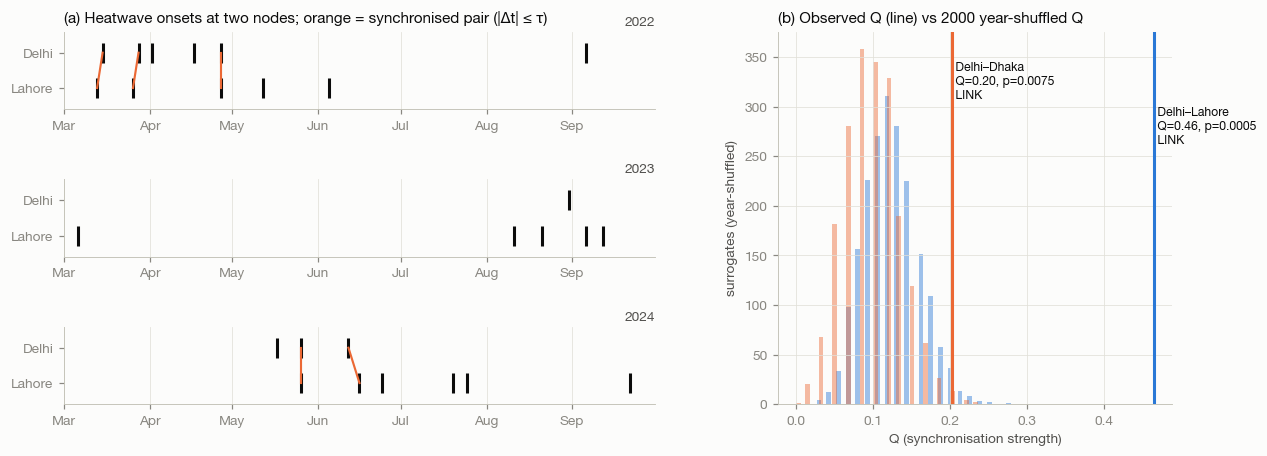

Delhi node near Delhi, Lahore node near Lahore, Dhaka node near Dhaka; distances: Delhi–Lahore 589 km, Delhi–Dhaka 1281 km


In [10]:
def pair_detail(i, j):
    S, L = es_year_tables(T_off[i], Y_idx[i], GAP[i], n_ev[i], T_off[j], Y_idx[j], GAP[j], n_ev[j], NY, TAU_MAX)
    norm = np.sqrt(n_ev[i] * n_ev[j])
    surr = S[np.arange(NY)[None, :], perms].sum(1) / norm
    return np.trace(S) / norm, surr

dl, lh, dh = node_of("Delhi"), node_of("Lahore"), node_of("Dhaka")
fig = plt.figure(figsize=(13, 4.4)); gs = fig.add_gridspec(3, 2, width_ratios=[1.5, 1], hspace=0.9, wspace=0.25)
for r, yr in enumerate([2022, 2023, 2024]):
    ax = fig.add_subplot(gs[r, 0]); y = np.where(YEARS == yr)[0][0]
    ei_ = T_off[dl, :n_ev[dl]][Y_idx[dl, :n_ev[dl]] == y]; ej_ = T_off[lh, :n_ev[lh]][Y_idx[lh, :n_ev[lh]] == y]
    gi_ = GAP[dl, :n_ev[dl]][Y_idx[dl, :n_ev[dl]] == y]; gj_ = GAP[lh, :n_ev[lh]][Y_idx[lh, :n_ev[lh]] == y]
    for a, ga in zip(ei_, gi_):
        for b, gb in zip(ej_, gj_):
            if abs(a - b) <= min(min(ga, gb) / 2, TAU_MAX):
                ax.plot([a, b], [1, 0], color=ORANGE, lw=1.4)
    ax.scatter(ei_, np.ones_like(ei_), marker="|", s=160, color=INK, lw=2)
    ax.scatter(ej_, np.zeros_like(ej_), marker="|", s=160, color=INK, lw=2)
    ax.set_ylim(-0.6, 1.6); ax.set_xlim(0, 214); ax.set_yticks([0, 1]); ax.set_yticklabels(["Lahore", "Delhi"])
    ax.set_xticks([0, 31, 61, 92, 122, 153, 184]); ax.set_xticklabels(["Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep"])
    ax.grid(axis="y", visible=False); ax.text(1.0, 1.08, str(yr), transform=ax.transAxes, ha="right", color=INK2)
    if r == 0:
        ax.set_title("(a) Heatwave onsets at two nodes; orange = synchronised pair (|Δt| ≤ τ)")
ax = fig.add_subplot(gs[:, 1])
for (i, j, name), c in zip([(dl, lh, "Delhi–Lahore"), (dl, dh, "Delhi–Dhaka")], [BLUE, ORANGE]):
    obs, surr = pair_detail(i, j)
    ax.hist(surr, bins=40, color=c, alpha=0.45, lw=0)
    ax.axvline(obs, color=c, lw=2)
    pval = P[i, j]
    ax.text(obs, ax.get_ylim()[1] * 0.92, f" {name}\n Q={obs:.2f}, p={pval:.4f}\n {'LINK' if A[i, j] else 'no link'}",
            color=INK, fontsize=8, va="top")
ax.set_xlabel("Q (synchronisation strength)"); ax.set_ylabel("surrogates (year-shuffled)")
ax.set_title("(b) Observed Q (line) vs 2000 year-shuffled Q")
save(fig, "fig02_event_sync_example")
print(f"Delhi node {place(dl)}, Lahore node {place(lh)}, Dhaka node {place(dh)}; distances: "
      f"Delhi–Lahore {D[dl, lh]:.0f} km, Delhi–Dhaka {D[dl, dh]:.0f} km")

**What this shows.** Delhi–Lahore (589 km): Q = 0.46, so almost half of their onsets coincide within ≤ 5 days. That is
higher than **all** 2000 year-shuffled values (p = 1/2001 ≈ 0.0005, the smallest possible with 2000 surrogates).
Delhi–Dhaka (1,281 km): Q = 0.20 is weaker but still above 99 % of the shuffles (p = 0.0075), so it is also a link.
Note where the shuffled values sit: around Q ≈ 0.1. That is how often onsets line up just because both places have
heatwaves at the same time of year. A link has to beat that seasonal baseline, not zero.

**Result of Part 2:** 13,523 links, **24 % of all pairs**. The network is dense because heatwave onsets over South Asia
are coherent over ~1000 km. This is not an artefact of the null model: a stricter null model (Part 5.2) is no sparser.
About 676 of these links (5 %) are expected to be false, and we don't know which ones. That matters a lot for the link view.

---
## Part 3 — NODE VIEW: summarise each row

Everything in this part is a **function of a node**: one number (or one label) per place.

| measure | calculation | question it answers |
|---|---|---|
| **degree** $k_i$ | $\sum_j A_{ij}$, count the links in row $i$ | with how many places does this place share heatwave timing? |
| **strength** $s_i$ | $\sum_j A_{ij}Q_{ij}$ | same, weighted by how strong the synchronisation is |
| **clustering** $C_i$ | share of $i$'s neighbour pairs that are themselves linked | is $i$ inside a tight, coherent patch? |
| **betweenness** $b_i$ | share of shortest paths between all other pairs that pass through $i$ | is $i$ a *gateway* between regions? |
| **node communities** | Louvain on nodes, weights $Q$ | which region does $i$ belong to? (exactly one) |
| **participation** $P_i$ | $1-\sum_c (k_{ic}/k_i)^2$ | how evenly are $i$'s links spread over communities? |

The figure below shows the step from matrix to node view: **each row collapses to a single number.**

In [11]:
ei = np.array(np.where(np.triu(A, 1))).T                     # link list (i < j)
E = len(ei)
g = ig.Graph(n=N, edges=ei.tolist()); g.es["Q"] = Q[ei[:, 0], ei[:, 1]]

degree = A.sum(1)
strength = np.where(A, Q, 0).sum(1)
clustering = np.array(g.transitivity_local_undirected(mode="zero"))
betweenness = np.array(g.betweenness()) / ((N - 1) * (N - 2) / 2)
node_comm, node_mod = best_louvain(g, weights="Q")
n_comm = node_comm.max() + 1
k_ic = np.stack([A[:, node_comm == c].sum(1) for c in range(n_comm)], 1)
participation = 1 - ((k_ic / degree[:, None]) ** 2).sum(1)

print(f"degree: min {degree.min()}, median {np.median(degree):.0f}, max {degree.max()}  "
      f"(each node is linked to {np.median(degree)/(N-1):.0%} of all others, median)")
print(f"node communities: {n_comm}, sizes {np.bincount(node_comm)}, modularity {node_mod:.2f}")
tbl = pd.DataFrame({"place": [place(n) for n in range(N)], "degree": degree, "strength": strength.round(1),
                    "clustering": clustering.round(2), "betweenness": betweenness.round(4), "community": node_comm})
print("\nTop 5 by degree:"); print(tbl.sort_values("degree", ascending=False).head(5).to_string())
print("\nTop 5 by betweenness:"); print(tbl.sort_values("betweenness", ascending=False).head(5).to_string())

degree: min 10, median 79, max 143  (each node is linked to 24% of all others, median)
node communities: 5, sizes [102  68  69  50  47], modularity 0.47



Top 5 by degree:
             place  degree  strength  clustering  betweenness  community
249  37.8°N 81.8°E     143      51.6        0.51       0.0091          4
247   near Kashgar     143      53.9        0.53       0.0080          4
248  37.8°N 79.8°E     143      52.1        0.52       0.0088          4
274  39.8°N 81.8°E     138      49.5        0.54       0.0082          4
217     near Kabul     138      50.7        0.57       0.0064          3

Top 5 by betweenness:
             place  degree  strength  clustering  betweenness  community
194     near Kabul     135      44.1        0.51       0.0154          1
169    near Multan     126      39.8        0.51       0.0133          1
170    near Lahore     117      37.1        0.52       0.0125          1
128     near Lhasa     100      27.0        0.44       0.0124          2
236  near Ashgabat      47      16.7        0.87       0.0122          3


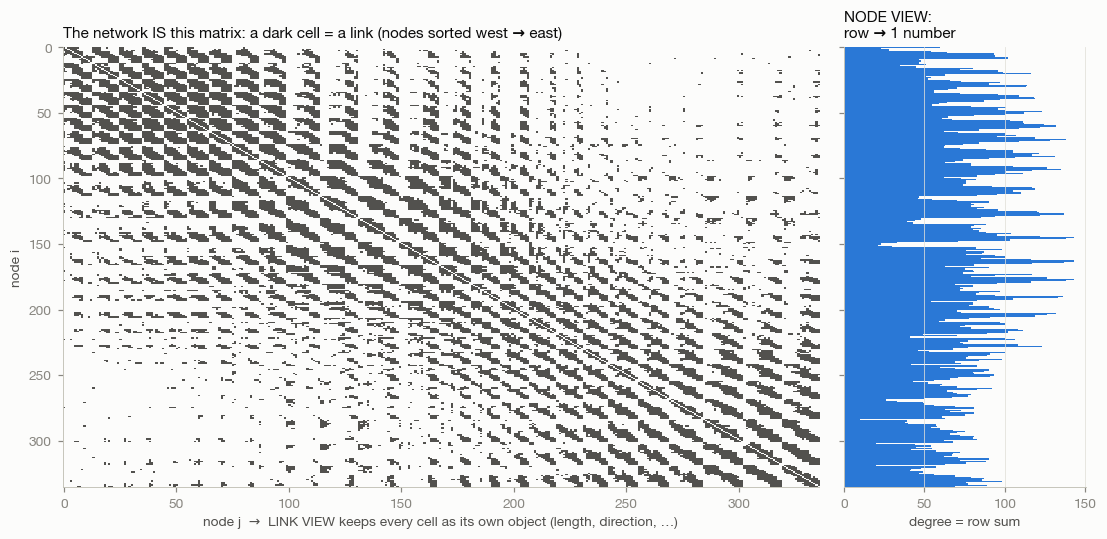

In [12]:
order = np.lexsort((lat, lon))          # west → east (same ordering as Fig. 1b)
fig = plt.figure(figsize=(12, 5.2)); gs = fig.add_gridspec(1, 2, width_ratios=[1, 0.32], wspace=0.05)
ax = fig.add_subplot(gs[0])
ax.imshow(np.where(A[np.ix_(order, order)], 1.0, np.nan), cmap=LinearSegmentedColormap.from_list("k", [INK2] * 2),
          interpolation="nearest", aspect="auto")
ax.set_title("The network IS this matrix: a dark cell = a link (nodes sorted west → east)")
ax.set_xlabel("node j  →  LINK VIEW keeps every cell as its own object (length, direction, …)")
ax.set_ylabel("node i"); ax.grid(False)
ax2 = fig.add_subplot(gs[1], sharey=ax)
ax2.barh(np.arange(N), degree[order], height=1.0, color=BLUE, lw=0)
ax2.set_xlabel("degree = row sum"); ax2.set_title("NODE VIEW:\nrow → 1 number"); ax2.tick_params(labelleft=False)
ax2.grid(axis="y", visible=False)
save(fig, "fig03_matrix_two_readings")

**What this shows.** With nodes sorted west → east, the matrix becomes diagonal bands: places near each other are linked.
The repeating stripes come from the sort order, which lists each 2° column of nodes from south to north. The bar on the
right is **all the node view keeps**: one number per row. *Which* cells in that row were dark (near or far, east or
west) is gone. The link view works on the dark cells themselves.

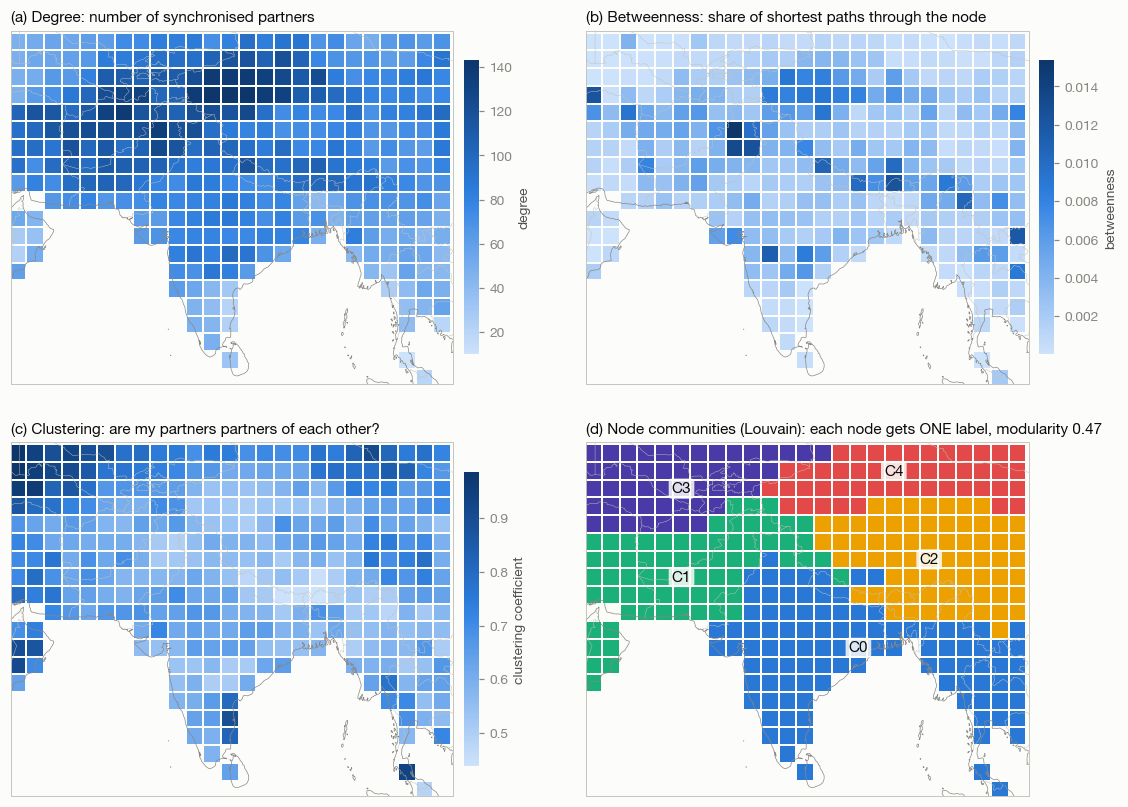

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(13, 9.2), subplot_kw=dict(projection=PC), gridspec_kw=dict(hspace=0.12, wspace=0.08))
base_map(axs[0, 0], "(a) Degree: number of synchronised partners"); node_map(axs[0, 0], degree, label="degree")
base_map(axs[0, 1], "(b) Betweenness: share of shortest paths through the node"); node_map(axs[0, 1], betweenness, label="betweenness")
base_map(axs[1, 0], "(c) Clustering: are my partners partners of each other?"); node_map(axs[1, 0], clustering, label="clustering coefficient")
ax = base_map(axs[1, 1], f"(d) Node communities (Louvain): each node gets ONE label, modularity {node_mod:.2f}")
cmap5 = mpl.colors.ListedColormap(CAT5[:n_comm]) if n_comm <= 5 else mpl.colormaps["tab10"]
node_map(ax, node_comm, cmap=cmap5, vmin=-0.5, vmax=n_comm - 0.5, cbar="space")
for c in range(n_comm):                 # direct labels: identity never by colour alone
    m = node_comm == c
    k = np.argmin(np.hypot(lat[m] - lat[m].mean(), lon[m] - lon[m].mean()))
    ax.text(lon[m][k], lat[m][k], f"C{c}", ha="center", va="center", fontsize=10, fontweight="bold", color=INK,
            bbox=dict(boxstyle="round,pad=0.2", fc=SURF, ec="none", alpha=0.85), transform=PC)
save(fig, "fig04_node_view_maps")

*Numbers in these notes are from the default parameters at the top. If you change a parameter, re-read the printed outputs instead.*


**What this shows (node view).**
* **(a) Degree** is highest over the Tarim Basin (around Kashgar, up to 143 partners) and over Afghanistan–Pakistan–NW
  India: large, dry, flat regions where one heat episode covers a big area. It is lowest in south India, Sri Lanka,
  Oman and the Malay peninsula. Part of that is a **boundary effect**: a node at a coast or at the edge of the map has
  fewer possible partners.
* **(b) Betweenness** peaks at a few gateway places: near Kabul, Multan, Lahore and Lhasa, which sit between regions (compare with d).
* **(c) Clustering** is highest in the far north-west and at the edges, where a node's partners are also each other's partners.
* **(d) 5 node communities**, each node with exactly one label: C0 monsoon India–Bangladesh–Myanmar–Indochina,
  C1 Iran–Afghanistan–Pakistan–NW India, C2 Tibetan Plateau and western China, C3 Central Asia, C4 Tarim Basin–Mongolia.
  This is the same kind of calculation as your walktrap partitions.

---
## Part 4 — LINK VIEW: keep every cell as an object

Each of the links now carries its own attributes:

| link attribute | calculation | question it answers |
|---|---|---|
| **length** $d_{ij}$ | great-circle distance | local coherence or long-range teleconnection? |
| **direction** $q_{ij}$ | ES lead–lag asymmetry | which way do heatwaves travel? |
| **edge betweenness** | share of shortest paths that use this *link* | which relationships are the bridges? |
| **link community** | Louvain on the line graph | which "family" of relationships is this link part of? |
| **bundle support** | how many links connect the *neighbourhoods* of $i$ and $j$ | is this link backed by its neighbours, or a lonely (possibly false) link? |

### 4.1 Length: how far do heatwave links reach?
For each distance band: (number of links) / (number of node pairs at that distance) = $P(\text{link}\mid d)$.
Dividing by the number of pairs is essential: in this domain most pairs of places are 1500–3500 km apart, so raw link
counts mostly reflect the geometry of the map.

### 4.2 Direction: only links can have a direction
For every link we know which end tends to go first, so we can draw an arrow from leader to follower. For all links
with a clear asymmetry ($|q|\ge 0.1$) we compute the compass bearing of that arrow.

In [14]:
d_link = D[ei[:, 0], ei[:, 1]]
Q_link = Q[ei[:, 0], ei[:, 1]]
q_link = q[ei[:, 0], ei[:, 1]]                 # > 0 → ei[:,1] leads ei[:,0]
leader = np.where(q_link > 0, ei[:, 1], ei[:, 0]); follower = np.where(q_link > 0, ei[:, 0], ei[:, 1])

bins = np.arange(0, 6001, 250); mids = bins[:-1] + 125
pairs_d = D[iu]
p_link_d = np.array([A[iu][(pairs_d >= a) & (pairs_d < b)].mean() if ((pairs_d >= a) & (pairs_d < b)).any() else np.nan
                     for a, b in zip(bins[:-1], bins[1:])])
n_pairs_d = np.histogram(pairs_d, bins)[0]

clear = np.abs(q_link) >= 0.1
dx = (lon[follower] - lon[leader]) * np.cos(np.radians((lat[follower] + lat[leader]) / 2))
dy = lat[follower] - lat[leader]
bearing = np.degrees(np.arctan2(dx, dy)) % 360          # 0 = towards north, 90 = towards east
east_share = np.mean(dx[clear] > 0)

# per-year check: for every link, does the WESTERN end lead more often that year?
west = np.where(lon[ei[:, 0]] < lon[ei[:, 1]], ei[:, 0], ei[:, 1]); east = np.where(west == ei[:, 0], ei[:, 1], ei[:, 0])
ok = lon[ei[:, 0]] != lon[ei[:, 1]]
net_y = Ly[east[ok], west[ok], :]                        # (east follows west) − (east leads west), per year
frac_west_leads = np.array([(net_y[:, y] > 0).sum() / max((net_y[:, y] != 0).sum(), 1) for y in range(NY)])

print(f"links: {E:,}; median length {np.median(d_link):.0f} km; longer than {LONG_KM} km: {np.sum(d_link > LONG_KM):,} ({np.mean(d_link > LONG_KM):.1%})")
print(f"links with clear direction (|q| ≥ 0.1): {clear.sum():,}; of these, leader is WEST of follower in {east_share:.0%}")
print(f"years in which west-leading links outnumber east-leading ones: {(frac_west_leads > 0.5).sum()} of {NY}")

links: 13,523; median length 909 km; longer than 2000 km: 1,246 (9.2%)
links with clear direction (|q| ≥ 0.1): 6,108; of these, leader is WEST of follower in 76%
years in which west-leading links outnumber east-leading ones: 24 of 26


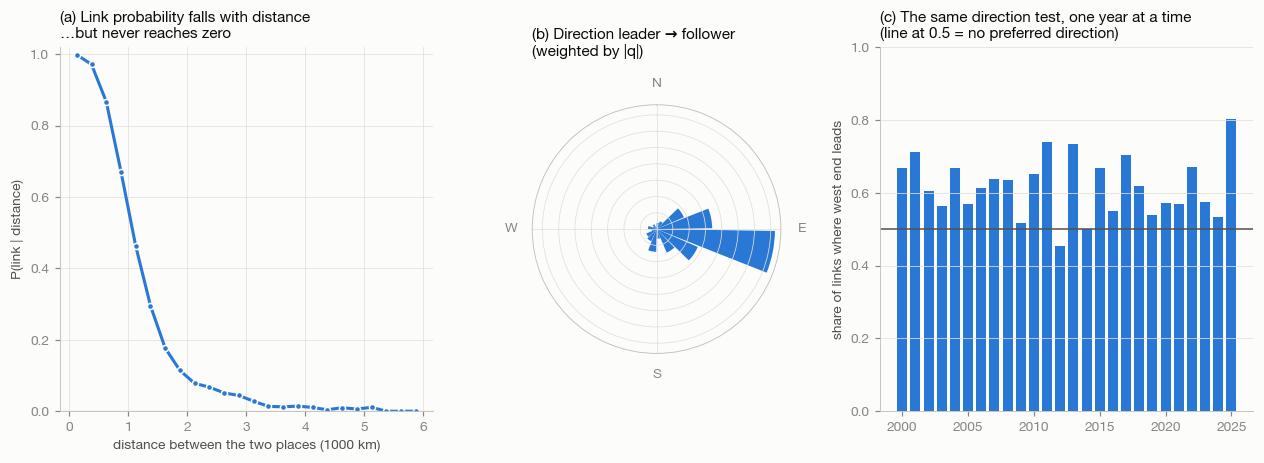

In [15]:
fig = plt.figure(figsize=(14, 4.3)); gs = fig.add_gridspec(1, 3, width_ratios=[1.2, 0.8, 1.2], wspace=0.3)
ax = fig.add_subplot(gs[0])
ax.plot(mids / 1000, p_link_d, color=BLUE, lw=2, marker="o", ms=4, mec=SURF, mew=1)
ax.set_xlabel("distance between the two places (1000 km)"); ax.set_ylabel("P(link | distance)")
ax.set_ylim(0, 1.02); ax.set_title("(a) Link probability falls with distance\n…but never reaches zero")
ax.axhline(0, color=AXISC, lw=0.8)
ax = fig.add_subplot(gs[1], projection="polar")
h, be = np.histogram(bearing[clear], bins=np.linspace(0, 360, 17), weights=np.abs(q_link[clear]))
ax.bar(np.radians(be[:-1] + 11.25), h, width=np.radians(22.5) * 0.92, color=BLUE, lw=0)
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1); ax.set_yticklabels([])
ax.set_xticks(np.radians([0, 90, 180, 270])); ax.set_xticklabels(["N", "E", "S", "W"])
ax.set_title("(b) Direction leader → follower\n(weighted by |q|)", pad=14)
ax = fig.add_subplot(gs[2])
ax.bar(YEARS, frac_west_leads, color=BLUE, width=0.75, lw=0)
ax.axhline(0.5, color=INK2, lw=1)
ax.set_ylim(0, 1); ax.set_ylabel("share of links where west end leads")
ax.set_title("(c) The same direction test, one year at a time\n(line at 0.5 = no preferred direction)"); ax.grid(axis="x", visible=False)
save(fig, "fig05_link_length_direction")

**What this shows (link view).**
* **(a)** Below ~500 km almost every pair is linked. The probability halves by ~1,200 km and falls to ~10 % by
  2,000 km, then a **long tail** of 1–8 % continues out to 5,000 km. 9 % of all links (1,246) are longer than 2,000 km.
  No node map can show this curve, because it is a property of links, grouped by distance.
* **(b)** For the 6,108 links with a clear direction, the leader → follower arrow points **east / east-south-east**
  much more often than any other way. The western end goes first in **76 %** of them.
* **(c)** The share of links where the west end leads is above 0.5 in **24 of 26 years** (2014 exactly 0.5, 2012
  below). It is a consistent pattern, not one big year, and it fits weather systems carried eastward by the
  mid-latitude westerlies. *Caveat:* this is descriptive. A formal test needs a null model built for direction (for
  example, randomly swapping which end of each synchronised pair came first).

### 4.3 Node view vs link view of the *same* direction information
A node view of direction collapses each node's links into one **net lead score**,
$\text{lead}_i = \sum_j A_{ij}\,q_{ji}$ (positive = this place usually heats up first, a "source").
The link view keeps the arrows, so it also shows **where** heat goes from each source.

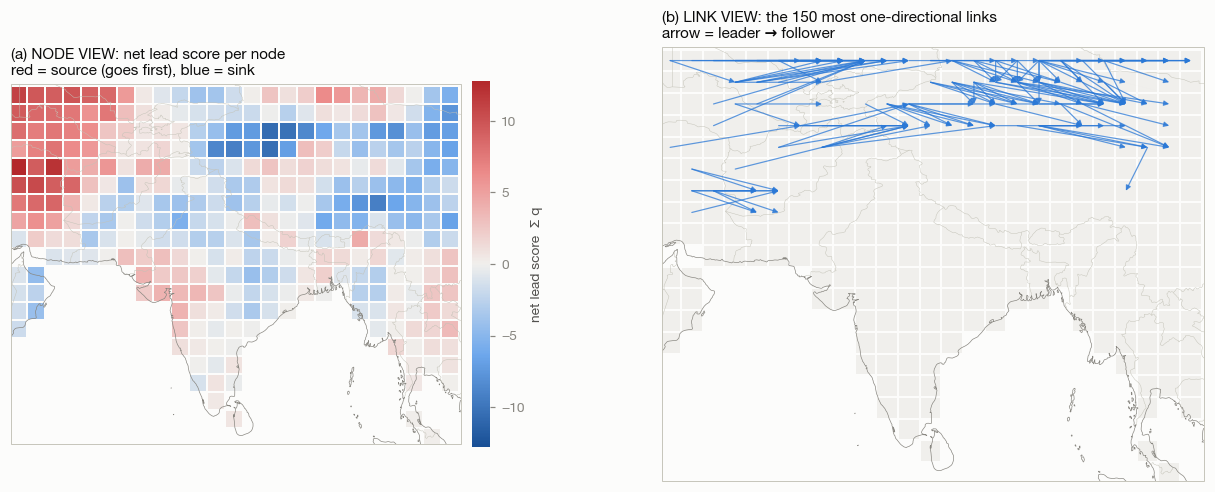

strongest sources (node view): ['35.8°N 55.8°E', 'near Mashhad', '43.8°N 55.8°E', '33.8°N 57.8°E']
strongest sinks   (node view): ['39.8°N 83.8°E', '37.8°N 83.8°E', '39.8°N 85.8°E', '31.8°N 95.8°E']
median length of the 150 most directional links: 653 km; leader west of follower in 95%


In [16]:
lead = np.where(A, q.T, 0).sum(1)
n_sync = Q_link * np.sqrt(n_ev[ei[:, 0]] * n_ev[ei[:, 1]])        # number of synchronised onset pairs per link
cand = np.where(n_sync >= 10)[0]
top_dir = cand[np.argsort(-np.abs(q_link[cand]))[:150]]

fig, axs = plt.subplots(1, 2, figsize=(14, 5.4), subplot_kw=dict(projection=PC))
ax = base_map(axs[0], "(a) NODE VIEW: net lead score per node\nred = source (goes first), blue = sink")
lim = np.abs(lead).max()
node_map(ax, lead, cmap=DIV, norm=TwoSlopeNorm(0, -lim, lim), label="net lead score  Σ q")
ax = base_map(axs[1], "(b) LINK VIEW: the 150 most one-directional links\narrow = leader → follower")
node_map(ax, np.zeros(N), cmap=LinearSegmentedColormap.from_list("bg", ["#f0efec"] * 2), cbar=False)
for k in top_dir:
    a, b = leader[k], follower[k]
    ax.annotate("", xy=(lon[b], lat[b]), xytext=(lon[a], lat[a]),
                arrowprops=dict(arrowstyle="-|>", color=BLUE, lw=0.8, alpha=0.75, mutation_scale=7, shrinkA=0, shrinkB=0))
save(fig, "fig06_direction_node_vs_link")
print(f"strongest sources (node view): {[place(n) for n in np.argsort(-lead)[:4]]}")
print(f"strongest sinks   (node view): {[place(n) for n in np.argsort(lead)[:4]]}")
print(f"median length of the 150 most directional links: {np.median(d_link[top_dir]):.0f} km; "
      f"leader west of follower in {np.mean(lon[follower[top_dir]] > lon[leader[top_dir]]):.0%}")

**What this shows.** Same $q$ values, two calculations.
* **(a) Node view:** the strongest "sources" are on the **western edge** of the map (Iran, Turkmenistan, near Mashhad),
  and the strongest "sinks" are in the Tarim Basin and Tibet. Be careful: part of this is the boundary effect again. If
  heat usually moves east, a node on the western edge can only *send*, because all its partners lie to its east.
* **(b) Link view:** the 150 most one-directional links are short (median 653 km), **95 % point west → east**, and they
  form chains along 35–44 °N, the mid-latitude westerly belt. Over monsoon India there are almost none. So the link
  view tells you *where the heat goes* and *where direction is strong at all*. The node map can show neither.

### 4.4 Bridges: node betweenness vs edge betweenness
Both use the same shortest paths. **Node** betweenness counts how many paths pass through a *place*;
**edge** betweenness counts how many paths use a *relationship*. In a spatial network, short links can always be bypassed,
so the paths pile up on a few long links, the shortcuts.

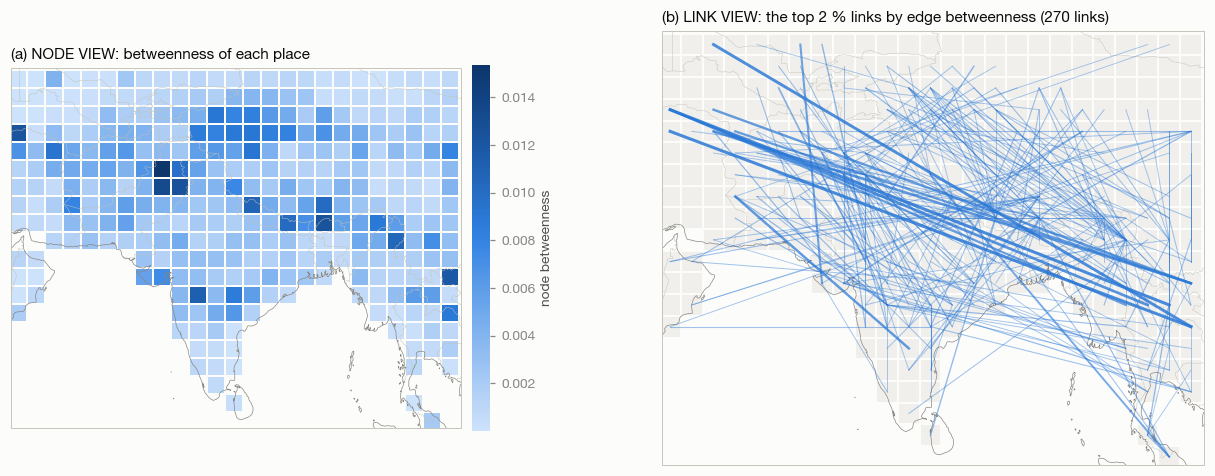

Spearman(edge betweenness, link length) = 0.44
median length: all links 909 km, top-2 % edge-betweenness links 1596 km


In [17]:
edge_btw = np.array(g.edge_betweenness())
top_eb = np.argsort(-edge_btw)[:int(0.02 * E)]
rho_eb_len = spearmanr(edge_btw, d_link)[0]

fig, axs = plt.subplots(1, 2, figsize=(14, 5.4), subplot_kw=dict(projection=PC))
base_map(axs[0], "(a) NODE VIEW: betweenness of each place"); node_map(axs[0], betweenness, label="node betweenness")
ax = base_map(axs[1], f"(b) LINK VIEW: the top 2 % links by edge betweenness ({len(top_eb)} links)")
node_map(ax, np.zeros(N), cmap=LinearSegmentedColormap.from_list("bg", ["#f0efec"] * 2), cbar=False)
eb_n = edge_btw[top_eb] / edge_btw[top_eb].max()
for k, s in zip(top_eb, eb_n):
    a, b = ei[k]
    ax.plot([lon[a], lon[b]], [lat[a], lat[b]], color=BLUE, lw=0.4 + 1.6 * s, alpha=0.35 + 0.5 * s, transform=PC)
save(fig, "fig07_bridges_node_vs_link")
print(f"Spearman(edge betweenness, link length) = {rho_eb_len:.2f}")
print(f"median length: all links {np.median(d_link):.0f} km, top-2 % edge-betweenness links {np.median(d_link[top_eb]):.0f} km")

**What this shows.** Node betweenness (a) picks out a few gateway *places*. Edge betweenness (b) picks out
*relationships*, and those turn out to be **long**: the top 2 % have a median length of **1,596 km** vs 909 km for all
links (Spearman ρ = 0.44 between edge betweenness and length). Many run NW → SE across the whole domain
(Iran/Afghanistan ↔ Bangladesh/Myanmar). In a spatial network short links can always be bypassed, so shortest paths
pile onto the few long shortcuts. Remember this for Part 5.2: the links that carry the most paths are the long ones,
and long links are the least trustworthy.

### 4.5 Link communities: every *link* gets one label, so nodes can have several
Same Louvain algorithm as Part 3, run on the line graph from Part 0 (each link becomes a node). This takes about a minute,
because the line graph has one node per link and over a million line-graph edges.

In [18]:
ei_lc, link_comm, link_mod = link_communities(A, n_runs=10)
assert np.array_equal(ei_lc, ei)
F = node_memberships(ei, link_comm, N)                           # share of node's links per link community
eff_memb = np.exp(-(np.where(F > 0, F * np.log(F), 0)).sum(1))     # effective number of communities (1 = pure)
n_10 = (F >= 0.10).sum(1)                                        # communities holding ≥ 10 % of a node's links
sizes = np.bincount(link_comm)
print(f"line graph: {E:,} nodes (= links) | {link_comm.max()+1} link communities, modularity {link_mod:.2f}")
print("sizes (links):", np.sort(sizes)[::-1])
print(f"nodes that belong to ≥ 2 link communities (each ≥ 10 % of their links): {(n_10 >= 2).sum()} of {N}")

line graph: 13,523 nodes (= links) | 9 link communities, modularity 0.55
sizes (links): [3475 2580 2575 2104 1816  360  271  211  131]
nodes that belong to ≥ 2 link communities (each ≥ 10 % of their links): 124 of 336


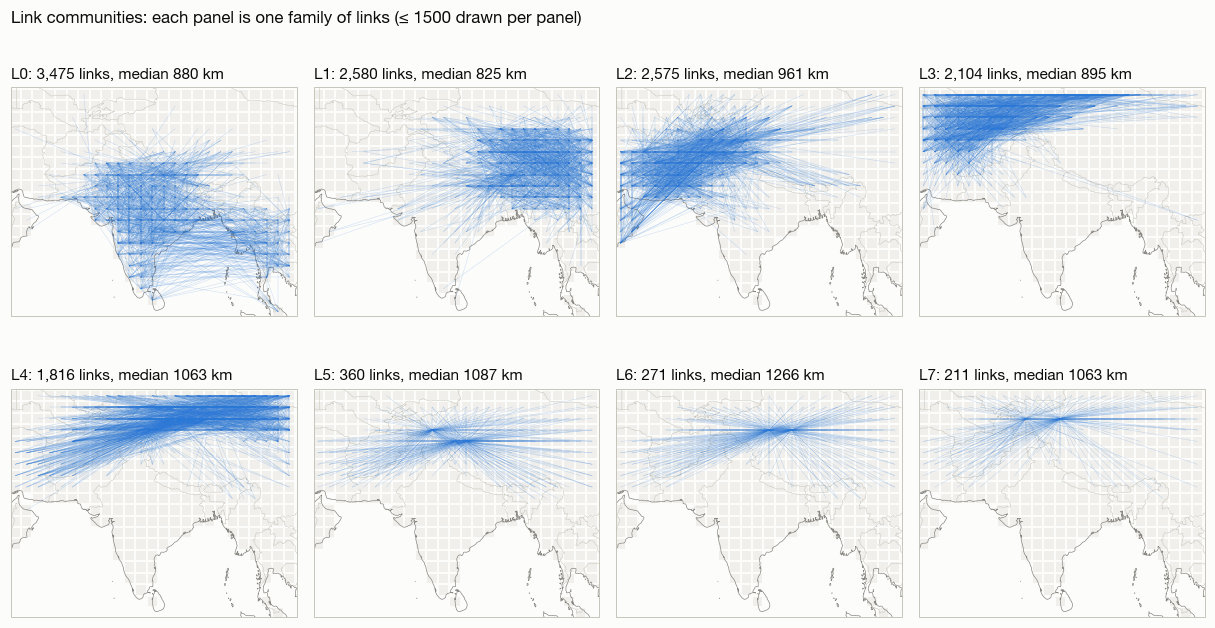

L0:  3475 links touch 217 nodes | busiest node      29.8°N 81.8°E (29.8°N 81.8°E) is an endpoint of 3% of them
L1:  2580 links touch 212 nodes | busiest node         near Lhasa (29.8°N 89.8°E) is an endpoint of 4% of them
L2:  2575 links touch 221 nodes | busiest node         near Kabul (33.8°N 71.8°E) is an endpoint of 5% of them
L3:  2104 links touch 145 nodes | busiest node      near Dushanbe (37.8°N 67.8°E) is an endpoint of 6% of them
L4:  1816 links touch 165 nodes | busiest node      39.8°N 83.8°E (39.8°N 83.8°E) is an endpoint of 7% of them
L5:   360 links touch 164 nodes | busiest node       near Kashgar (37.8°N 75.8°E) is an endpoint of 38% of them
L6:   271 links touch 152 nodes | busiest node      37.8°N 81.8°E (37.8°N 81.8°E) is an endpoint of 53% of them
L7:   211 links touch 142 nodes | busiest node      39.8°N 79.8°E (39.8°N 79.8°E) is an endpoint of 62% of them


In [19]:
show = np.argsort(-sizes)[:8]
fig, axs = plt.subplots(2, 4, figsize=(14, 6.4), subplot_kw=dict(projection=PC), gridspec_kw=dict(hspace=0.25, wspace=0.06))
for ax, c in zip(axs.flat, show):
    m = link_comm == c
    base_map(ax, f"L{c}: {m.sum():,} links, median {np.median(d_link[m]):.0f} km")
    node_map(ax, np.zeros(N), cmap=LinearSegmentedColormap.from_list("bg", ["#f0efec"] * 2), cbar=False)
    sel = np.where(m)[0]
    if len(sel) > 1500:
        sel = rng.choice(sel, 1500, replace=False)
    for k in sel:
        a, b = ei[k]
        ax.plot([lon[a], lon[b]], [lat[a], lat[b]], color=BLUE, lw=0.3, alpha=0.25, transform=PC)
    ax.title.set_fontsize(9)
for ax in axs.flat[len(show):]:
    ax.set_visible(False)
fig.suptitle("Link communities: each panel is one family of links (≤ 1500 drawn per panel)", x=0.125, ha="left",
             fontweight="bold", fontsize=11)
save(fig, "fig08_link_communities")
for c in show:                                   # is a community spread out, or a "star" around one node?
    m = link_comm == c
    hub = np.bincount(ei[m].ravel(), minlength=N)
    h = int(np.argmax(hub))
    print(f"L{c}: {m.sum():5d} links touch {np.sum(hub > 0):3d} nodes | busiest node {place(h):>18s} "
          f"({lat[h]:.1f}°N {lon[h]:.1f}°E) is an endpoint of {hub[h] / m.sum():.0%} of them")

**What this shows.** 9 link communities (modularity 0.55).
* **L0–L4 are regional families** that roughly match the node communities: monsoon India, Tibet / west China,
  Afghanistan–Pakistan, Central Asia, and the northern belt. Unlike node communities, their links **reach outside** their core region.
* **L5–L7 are stars:** 38–62 % of their links touch one node in the Tarim Basin (near Kashgar, 37.8°N 81.8°E,
  39.8°N 79.8°E). These are the same nodes that top the degree ranking in Part 3. So the link view splits that high
  degree in two: a regional part, plus a **separate family of long links** (median 1,060–1,270 km) fanning out across
  the domain. Their far ends share few partners with each other, so they fit no regional family. The degree map only
  says "most connected".

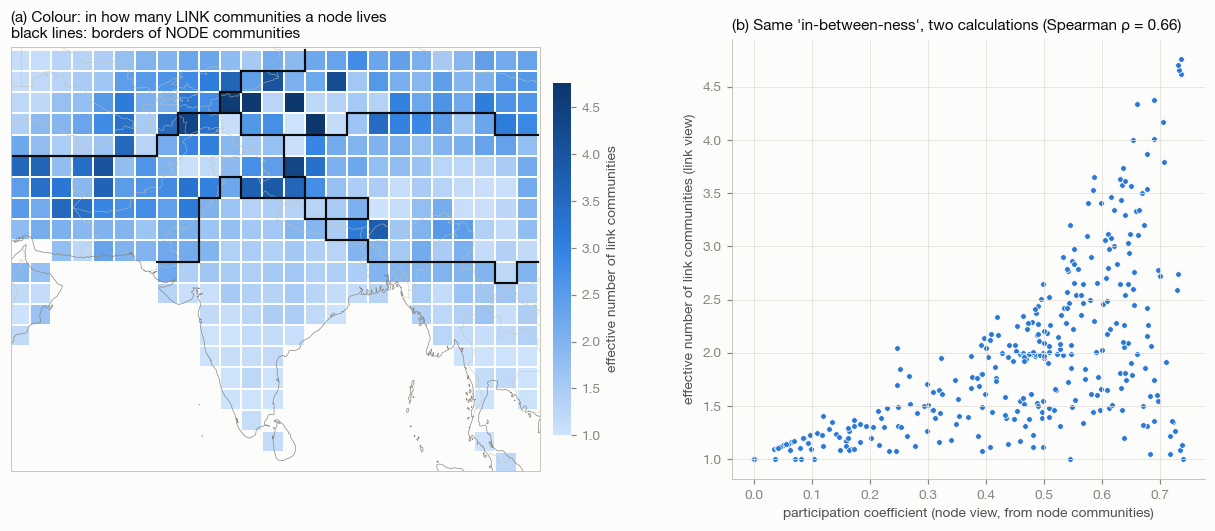

median effective # link communities: border nodes 2.06 vs interior nodes 1.52


In [20]:
def partition_boundaries(ax, labels):
    """Draw lines on the 2° grid wherever neighbouring nodes belong to different node communities."""
    Gl = to_grid(labels)
    for r in range(Gl.shape[0]):
        for c in range(Gl.shape[1]):
            if np.isnan(Gl[r, c]):
                continue
            if c + 1 < Gl.shape[1] and not np.isnan(Gl[r, c + 1]) and Gl[r, c] != Gl[r, c + 1]:
                ax.plot([lon_e[c + 1]] * 2, [lat_e[r], lat_e[r + 1]], color=INK, lw=1.4, transform=PC)
            if r + 1 < Gl.shape[0] and not np.isnan(Gl[r + 1, c]) and Gl[r, c] != Gl[r + 1, c]:
                ax.plot([lon_e[c], lon_e[c + 1]], [lat_e[r + 1]] * 2, color=INK, lw=1.4, transform=PC)

rho_pc = spearmanr(participation, eff_memb)[0]
fig = plt.figure(figsize=(14, 5.2)); gs = fig.add_gridspec(1, 2, width_ratios=[1.35, 1], wspace=0.15)
ax = base_map(fig.add_subplot(gs[0], projection=PC),
              "(a) Colour: in how many LINK communities a node lives\nblack lines: borders of NODE communities")
node_map(ax, eff_memb, label="effective number of link communities")
partition_boundaries(ax, node_comm)
ax = fig.add_subplot(gs[1])
ax.scatter(participation, eff_memb, s=14, color=BLUE, edgecolor=SURF, lw=0.5)
ax.set_xlabel("participation coefficient (node view, from node communities)")
ax.set_ylabel("effective number of link communities (link view)")
ax.set_title(f"(b) Same 'in-between-ness', two calculations (Spearman ρ = {rho_pc:.2f})")
save(fig, "fig09_overlap_boundaries")
on_border = np.array([any(node_comm[m] != node_comm[n] for m in np.where((D[n] < 300) & (D[n] > 0))[0]) for n in range(N)])
print(f"median effective # link communities: border nodes {np.median(eff_memb[on_border]):.2f} "
      f"vs interior nodes {np.median(eff_memb[~on_border]):.2f}")

**What this shows.** (a) Nodes that belong to several link communities (dark) sit mostly **along the borders of the
node communities** (black lines). The median effective number of link communities is 2.06 for border nodes vs 1.52 for
interior nodes. 124 of 336 nodes have ≥ 10 % of their links in at least two link communities.
(b) The node-view measure of in-between-ness (participation coefficient) and the link-view measure agree only
moderately (ρ = 0.66). The link view adds *which* communities a node belongs to and *in what proportion* (the row
`F[n]`). A node with 40 % of its links in the Afghanistan–Pakistan family and 60 % in the monsoon-India family is
genuinely part of both heatwave systems. A node partition has to call it one or the other.

### 4.6 Bundle support: a single link is a weak witness
With ~56 000 tests and FDR 5 %, a few hundred of our links are false, and false links are mostly **long** (most pairs are
far apart). A link-level check: if heatwaves at $i$ and $j$ are truly coupled, then the places *around* $i$ (within
450 km) should also be linked to the places around $j$, because temperature fields are spatially smooth. So for each link:

$$\text{support ratio}_{ij} = \frac{\text{share of (neighbour of } i,\ \text{neighbour of } j) \text{ pairs that are linked}}
{P(\text{link}\mid d_{ij}) \text{ from 4.1}}$$

A ratio ≈ 1 means the link's neighbourhood looks like a random pair at that distance (an isolated, suspicious link).
A ratio ≫ 1 means the link sits inside a **bundle** of parallel links (a credible teleconnection). This is a simplified
form of the link-bundling idea in Boers et al. (2019, *Nature*).

In [21]:
nbhd = [np.where(D[i] <= BUNDLE_R)[0] for i in range(N)]
def p_link_at(Am, d):
    pd_ = np.array([Am[iu][(pairs_d >= a) & (pairs_d < b)].mean() for a, b in zip(bins[:-1], bins[1:])])
    return pd_[np.clip(np.digitize(d, bins) - 1, 0, len(pd_) - 1)]

def support_ratio(Am, links):
    sup = np.empty(len(links))
    for k, (i, j) in enumerate(links):
        block = Am[np.ix_(nbhd[i], nbhd[j])]
        sup[k] = (block.sum() - Am[i, j]) / (block.size - 1)
    return sup / p_link_at(Am, D[links[:, 0], links[:, 1]])

long_idx = np.where(d_link > LONG_KM)[0]
ratio_long = support_ratio(A, ei[long_idx])
print(f"long links (> {LONG_KM} km): {len(long_idx):,}; support ratio median {np.median(ratio_long):.1f}; "
      f"bundled (ratio ≥ 2): {np.mean(ratio_long >= 2):.0%}; weakly supported (< 2): {np.sum(ratio_long < 2)}")

# test: do injected FAKE links look different? add 5 % random non-links, recompute support for long links
nonlinks = np.array([(i, j) for i, j in zip(*iu) if not A[i, j]])
fake = nonlinks[rng.choice(len(nonlinks), int(0.05 * E), replace=False)]
A_fake = A.copy(); A_fake[fake[:, 0], fake[:, 1]] = A_fake[fake[:, 1], fake[:, 0]] = True
fake_long = fake[D[fake[:, 0], fake[:, 1]] > LONG_KM]
r_real = support_ratio(A_fake, ei[long_idx]); r_fake = support_ratio(A_fake, fake_long)
print(f"after injecting {len(fake)} fake links: flagged as weak (ratio < 2) → real long links {np.mean(r_real < 2):.0%}, "
      f"fake long links {np.mean(r_fake < 2):.0%}")

long links (> 2000 km): 1,246; support ratio median 6.0; bundled (ratio ≥ 2): 87%; weakly supported (< 2): 162
after injecting 676 fake links: flagged as weak (ratio < 2) → real long links 15%, fake long links 89%


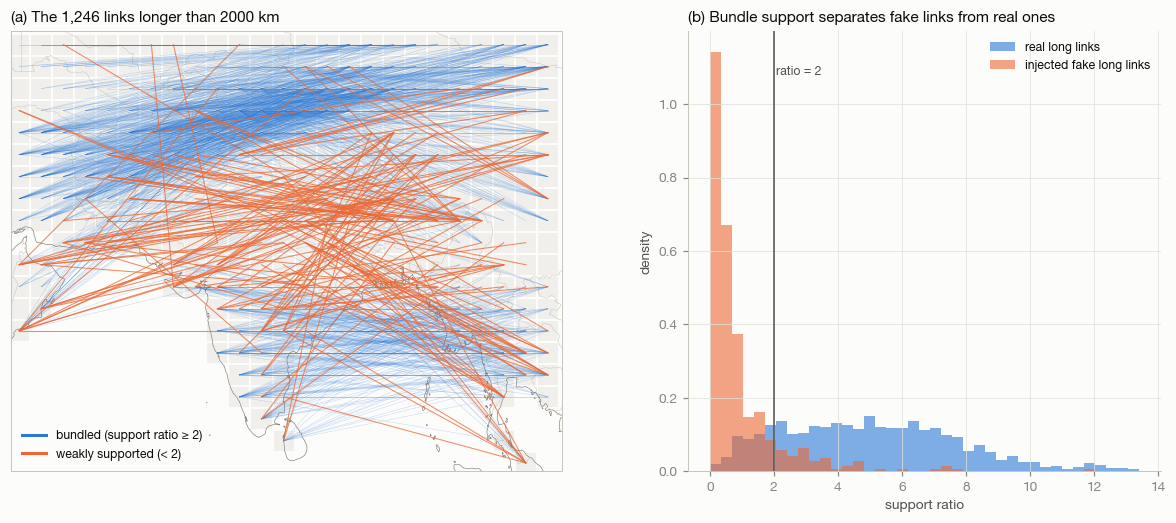

In [22]:
fig = plt.figure(figsize=(14, 5.2)); gs = fig.add_gridspec(1, 2, width_ratios=[1.35, 1], wspace=0.15)
ax = base_map(fig.add_subplot(gs[0], projection=PC), f"(a) The {len(long_idx):,} links longer than {LONG_KM} km")
node_map(ax, np.zeros(N), cmap=LinearSegmentedColormap.from_list("bg", ["#f0efec"] * 2), cbar=False)
for k, r in zip(long_idx, ratio_long):
    a, b = ei[k]
    if r >= 2:
        ax.plot([lon[a], lon[b]], [lat[a], lat[b]], color=BLUE, lw=0.35, alpha=0.25, transform=PC)
for k, r in zip(long_idx, ratio_long):
    a, b = ei[k]
    if r < 2:
        ax.plot([lon[a], lon[b]], [lat[a], lat[b]], color=ORANGE, lw=0.7, alpha=0.75, transform=PC)
ax.plot([], [], color=BLUE, lw=2, label="bundled (support ratio ≥ 2)")
ax.plot([], [], color=ORANGE, lw=2, label="weakly supported (< 2)")
ax.legend(loc="lower left", fontsize=8, facecolor=SURF, framealpha=0.9, frameon=True, edgecolor="none")
ax = fig.add_subplot(gs[1])
hb = np.linspace(0, max(np.percentile(r_real, 98), 4), 40)
ax.hist(r_real, bins=hb, color=BLUE, alpha=0.6, density=True, lw=0, label="real long links")
ax.hist(r_fake, bins=hb, color=ORANGE, alpha=0.6, density=True, lw=0, label="injected fake long links")
ax.axvline(2, color=INK2, lw=1); ax.text(2.05, ax.get_ylim()[1] * 0.9, "ratio = 2", color=INK2, fontsize=8)
ax.set_xlabel("support ratio"); ax.set_ylabel("density"); ax.legend(fontsize=8)
ax.set_title("(b) Bundle support separates fake links from real ones")
save(fig, "fig10_bundle_support")

**What this shows.** Most long links are **bundled**: 87 % have a support ratio ≥ 2 (median 6), meaning their
neighbourhoods are linked too. The bundled links run mainly **west–east, along latitude**. The 162 weakly supported
ones (orange) cut diagonally across the domain with no consistent pattern, which is how noise would look.
(b) The injection test shows the check works: 89 % of fake long links are flagged weak, against 15 % of real long
links. Degree cannot do this, because a fake link adds +1 to two nodes exactly like a real one.

---
## Part 5 — Head-to-head

### 5.1 Same degree, different story
Degree says how many links a place has. It says nothing about **where** they go. Below: two nodes with almost the same
degree, chosen automatically as the ones with the shortest and the longest average link among nodes within ±10 % of the
median degree.

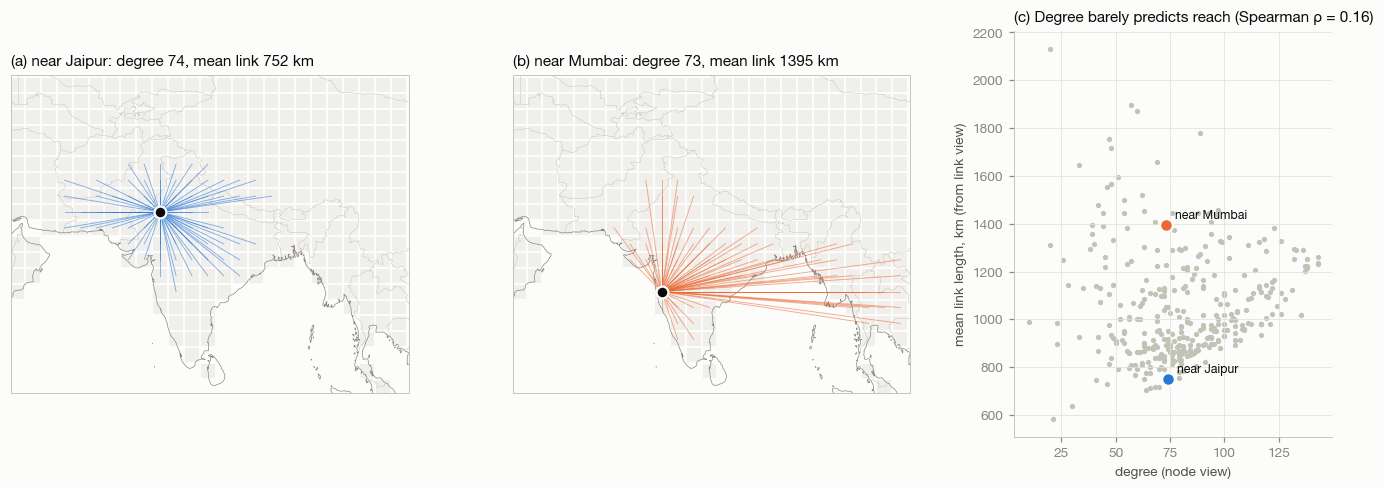

In [23]:
mean_len = np.where(A, D, 0).sum(1) / degree
rho_deg_len = spearmanr(degree, mean_len)[0]
# only interior nodes (≥ 2 cells from the domain edge): an edge node's links can only point inwards,
# which would make its reach a property of the map frame, not of the climate
interior = (lat > lat_c[1]) & (lat < lat_c[-2]) & (lon > lon_c[1]) & (lon < lon_c[-2])
band = np.where(interior & (np.abs(degree - np.median(degree)) <= 0.10 * np.median(degree)))[0]
n_short, n_long = band[np.argmin(mean_len[band])], band[np.argmax(mean_len[band])]

fig = plt.figure(figsize=(15.5, 4.8)); gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.8], wspace=0.28)
for col, (n, c) in enumerate([(n_short, BLUE), (n_long, ORANGE)]):
    ax = base_map(fig.add_subplot(gs[col], projection=PC),
                  f"({'ab'[col]}) {place(n)}: degree {degree[n]}, mean link {mean_len[n]:.0f} km")
    node_map(ax, np.zeros(N), cmap=LinearSegmentedColormap.from_list("bg", ["#f0efec"] * 2), cbar=False)
    for m in np.where(A[n])[0]:
        ax.plot([lon[n], lon[m]], [lat[n], lat[m]], color=c, lw=0.6, alpha=0.55, transform=PC)
    ax.scatter(lon[n], lat[n], s=60, color=INK, edgecolor=SURF, lw=1.5, zorder=5, transform=PC)
ax = fig.add_subplot(gs[2])
ax.scatter(degree, mean_len, s=12, color=AXISC, lw=0)
for n, c in [(n_short, BLUE), (n_long, ORANGE)]:
    ax.scatter(degree[n], mean_len[n], s=70, color=c, edgecolor=SURF, lw=1.5, zorder=3)
    ax.annotate(place(n), (degree[n], mean_len[n]), xytext=(6, 4), textcoords="offset points", fontsize=8, color=INK)
ax.set_xlabel("degree (node view)"); ax.set_ylabel("mean link length, km (from link view)")
ax.set_title(f"(c) Degree barely predicts reach (Spearman ρ = {rho_deg_len:.2f})")
save(fig, "fig11_same_degree_different_story")

**What this shows.** The nodes near Jaipur and near Mumbai have almost the same degree (74 vs 73), so the node view
treats them as equivalent. Their links tell different stories. Jaipur's heatwave partners form a compact ring within
about 1,000 km (mean 752 km). Mumbai's reach across the Bay of Bengal to Bangladesh and Myanmar (mean 1,395 km). Across
all nodes, degree barely predicts mean link length (ρ = 0.16). *Mean link length* is a hybrid: a link property
summarised per node. Hybrids are a cheap way to get some link information back into a node map.

### 5.2 Robustness: which conclusions survive?
Two stress tests:

1. **Noise injection.** Add 1–20 % fake random links (a stand-in for the false positives every significance test lets
   through) and ask how similar each result stays to the original. Five repeats per noise level.
2. **A different but equally reasonable null model.** Rebuild the network with a *time-shift* null instead of a year
   shuffle: each year, slide node $j$'s onsets by 11–30 days. This keeps each year's heatwave count and only breaks day-level
   timing.

Similarity scores: **Spearman ρ** for rankings of node values, **NMI** for community partitions, **Jaccard** = |shared| / |union|
for sets of links. All are 1.0 when nothing changes.

In [24]:
def summarise(Am):
    e = np.array(np.where(np.triu(Am, 1))).T
    gg = ig.Graph(n=N, edges=e.tolist())
    eb = np.array(gg.edge_betweenness())
    dl_ = D[e[:, 0], e[:, 1]]
    return dict(deg=Am.sum(1), btw=np.array(gg.betweenness()), comm=best_louvain(gg, n_runs=5)[0],
                long={tuple(x) for x in e[dl_ > LONG_KM]}, topeb={tuple(x) for x in e[np.argsort(-eb)[:len(e) // 20]]},
                links={tuple(x) for x in e})

jac = lambda a, b: len(a & b) / len(a | b)
def compare(r0, r1):
    return {"degree (node)": spearmanr(r0["deg"], r1["deg"])[0],
            "node communities (node)": nmi(r0["comm"], r1["comm"]),
            "betweenness (node, path-based)": spearmanr(r0["btw"], r1["btw"])[0],
            "long links > 2000 km (link)": jac(r0["long"], r1["long"]),
            "top-5 % edge-betweenness links (link)": jac(r0["topeb"], r1["topeb"])}

ref = summarise(A)
rows = []
for frac in [0.01, 0.02, 0.05, 0.10, 0.20]:
    for rep in range(5):
        add = nonlinks[rng.choice(len(nonlinks), int(frac * E), replace=False)]
        An = A.copy(); An[add[:, 0], add[:, 1]] = An[add[:, 1], add[:, 0]] = True
        rows.append({"noise": frac, **compare(ref, summarise(An))})
noise_df = pd.DataFrame(rows).groupby("noise").mean()
noise_df.round(3)

,degree (node),node communities (node),"betweenness (node, path-based)",long links > 2000 km (link),top-5 % edge-betweenness links (link)
noise,,,,,
0.01,0.999,0.954,0.875,0.935,0.608
0.02,0.998,0.978,0.833,0.873,0.451
0.05,0.996,0.966,0.776,0.744,0.177
0.10,0.993,0.948,0.767,0.588,0.020
0.20,0.984,0.956,0.752,0.418,0.006


In [25]:
SH = np.array([s for s in range(-30, 31) if abs(s) > 10])

@njit
def shift_tables(Ti, Yi, Gi, ni, Tj, Yj, Gj, nj, NY, tau_max, SH):
    C = np.zeros((NY, len(SH) + 1))          # column 0 = observed, column s+1 = j shifted by SH[s] days
    for a in range(ni):
        for b in range(nj):
            if Yi[a] != Yj[b]:
                continue
            tau = min(min(Gi[a], Gj[b]) / 2.0, tau_max)
            if abs(Ti[a] - Tj[b]) <= tau:
                C[Yi[a], 0] += 1.0
            for s in range(len(SH)):
                if abs(Ti[a] - (Tj[b] + SH[s])) <= tau:
                    C[Yi[a], s + 1] += 1.0
    return C

@njit(parallel=True)
def shift_null_p(T, Y, G, n_ev, NY, tau_max, SH, draws):
    N = T.shape[0]; NS = draws.shape[0]; P = np.ones((N, N))
    for i in prange(N):
        for j in range(i + 1, N):
            C = shift_tables(T[i], Y[i], G[i], n_ev[i], T[j], Y[j], G[j], n_ev[j], NY, tau_max, SH)
            obs = C[:, 0].sum(); ge = 0
            for s in range(NS):
                v = 0.0
                for y in range(NY):
                    v += C[y, draws[s, y]]
                if v >= obs:
                    ge += 1
            P[i, j] = P[j, i] = (ge + 1.0) / (NS + 1.0)
    return P

P_shift = shift_null_p(T_off, Y_idx, GAP, n_ev, NY, TAU_MAX, SH, rng.integers(1, len(SH) + 1, size=(N_SURR, NY)))
sig_shift = bh_fdr(P_shift[iu], FDR_Q)
A_shift = np.zeros((N, N), bool); A_shift[iu[0][sig_shift], iu[1][sig_shift]] = True; A_shift |= A_shift.T
alt = compare(ref, summarise(A_shift)); alt["ALL links (link)"] = jac(ref["links"], summarise(A_shift)["links"])
print(f"time-shift null: {sig_shift.sum():,} links (year-shuffle null: {E:,})")
pd.Series(alt).round(3)

time-shift null: 15,931 links (year-shuffle null: 13,523)


degree (node)                            0.916
node communities (node)                  0.849
betweenness (node, path-based)           0.781
long links > 2000 km (link)              0.433
top-5 % edge-betweenness links (link)    0.083
ALL links (link)                         0.781
dtype: float64

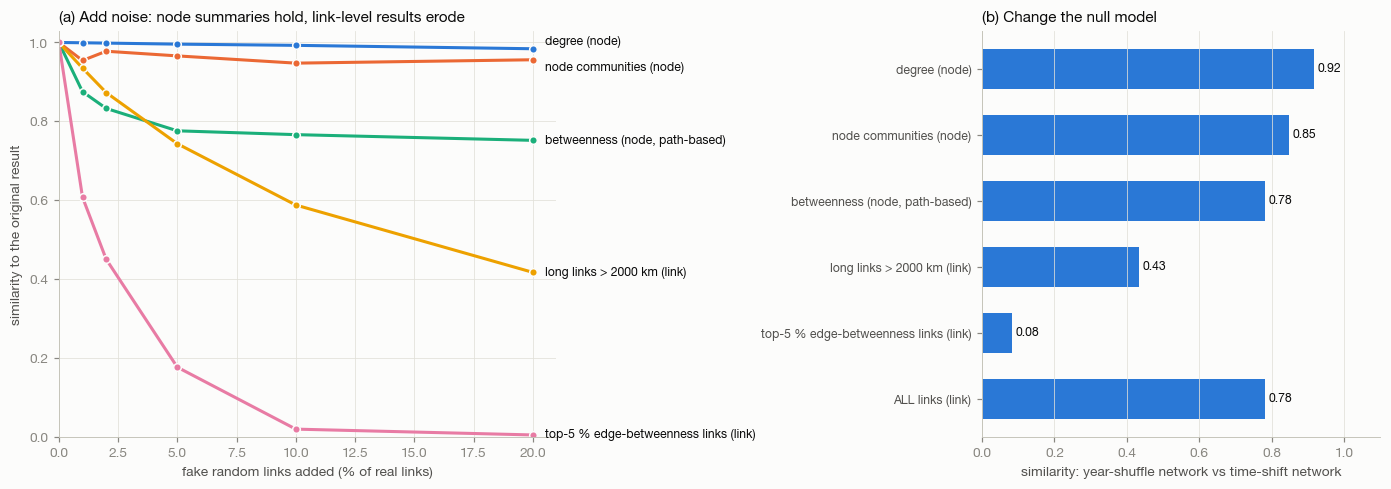

In [26]:
fig = plt.figure(figsize=(15.5, 4.8)); gs = fig.add_gridspec(1, 2, width_ratios=[1.25, 1], wspace=0.95)
ax = fig.add_subplot(gs[0])
x = np.r_[0, noise_df.index.values * 100]
nudge = {"degree (node)": 5, "node communities (node)": -5}       # two end values sit close together
for col, c in zip(noise_df.columns, SERIES):
    y = np.r_[1.0, noise_df[col].values]
    ax.plot(x, y, color=c, lw=2, marker="o", ms=5, mec=SURF, mew=1, label=col)
    ax.annotate(col, (x[-1], y[-1]), xytext=(8, nudge.get(col, 0)), textcoords="offset points", va="center",
                fontsize=8, color=INK, annotation_clip=False)
ax.set_xlabel("fake random links added (% of real links)"); ax.set_ylabel("similarity to the original result")
ax.set_ylim(0, 1.03); ax.set_xlim(0, 21)
ax.set_title("(a) Add noise: node summaries hold, link-level results erode")
ax = fig.add_subplot(gs[1])
labels = list(alt.keys()); vals = np.array(list(alt.values()))
yy = np.arange(len(labels))[::-1]
ax.barh(yy, vals, color=BLUE, height=0.6, lw=0)
for yv, v in zip(yy, vals):
    ax.text(v + 0.01, yv, f"{v:.2f}", va="center", fontsize=8, color=INK)
ax.set_yticks(yy); ax.set_yticklabels(labels, fontsize=8, color=INK2); ax.set_xlim(0, 1.1)
ax.set_xlabel("similarity: year-shuffle network vs time-shift network")
ax.set_title("(b) Change the null model"); ax.grid(axis="y", visible=False)
save(fig, "fig12_robustness")

**What this shows.**
* **(a) Noise.** Adding 5 % fake links leaves degree almost untouched (ρ = 0.996) and node communities stable
  (NMI ≈ 0.97). Meanwhile the set of long links is already 26 % different (Jaccard 0.74), and the top bridge links are
  82 % different (0.18). At 10 % noise the bridges are almost completely replaced (0.02). **Node betweenness** sits in
  between (≈ 0.78): it gives one number per node but is computed from paths, so it inherits the fragility of links.
* **(b) Null model.** An equally defensible null model keeps degree (0.92), node communities (0.85) and 78 % of all
  links, yet only **43 % of the long links** and **8 % of the top bridges** survive.

---
## Part 6 — Summary

In [27]:
summary = pd.DataFrame([
    ["How connected is each place?", "degree / strength map (Fig 4a)", "–",
     f"median node linked to {np.median(degree)/(N-1):.0%} of all others"],
    ["Which regions belong together?", f"{n_comm} node communities, one label each (Fig 4d)",
     f"{link_comm.max()+1} link communities; {(n_10>=2).sum()} of {N} nodes in ≥ 2 (Fig 8–9)",
     f"overlap concentrates on node-community borders (ρ = {rho_pc:.2f} with participation)"],
    ["How far do heatwave links reach?", "mean link length per node (a link property, summarised)",
     "P(link | distance) (Fig 5a)", f"{np.mean(d_link > LONG_KM):.0%} of links are longer than {LONG_KM} km"],
    ["Which way do heatwaves move?", "net lead score: sources vs sinks (Fig 6a)", "arrows + bearing rose (Fig 5b, 6b)",
     f"leader is west of follower in {east_share:.0%} of directional links; {(frac_west_leads>0.5).sum()}/{NY} years"],
    ["Where are the bridges?", "node betweenness (Fig 7a)", "edge betweenness (Fig 7b)",
     f"edge betweenness rises with link length (ρ = {rho_eb_len:.2f})"],
    ["Can I trust a single long link?", "– (degree absorbs it silently)", "bundle support ratio (Fig 10)",
     f"{np.mean(r_fake<2):.0%} of fake vs {np.mean(r_real<2):.0%} of real long links flagged"],
    ["Same degree = same role?", "yes, identical numbers", "no: link lengths differ (Fig 11)",
     f"degree vs mean link length ρ = {rho_deg_len:.2f}"],
    ["What survives 5 % noise?", f"degree ρ = {noise_df.loc[0.05].iloc[0]:.3f}, communities NMI = {noise_df.loc[0.05].iloc[1]:.2f}",
     f"long links J = {noise_df.loc[0.05].iloc[3]:.2f}, top bridges J = {noise_df.loc[0.05].iloc[4]:.2f}", "Fig 12"],
], columns=["question", "node view", "link view", "result in this data"])
pd.set_option("display.max_colwidth", 90)
summary

,question,node view,link view,result in this data
0,How connected is each place?,degree / strength map (Fig 4a),–,median node linked to 24% of all others
1,Which regions belong together?,"5 node communities, one label each (Fig 4d)",9 link communities; 124 of 336 nodes in ≥ 2 (Fig 8–9),overlap concentrates on node-community borders (ρ = 0.66 with participation)
2,How far do heatwave links reach?,"mean link length per node (a link property, summarised)",P(link | distance) (Fig 5a),9% of links are longer than 2000 km
3,Which way do heatwaves move?,net lead score: sources vs sinks (Fig 6a),"arrows + bearing rose (Fig 5b, 6b)",leader is west of follower in 76% of directional links; 24/26 years
4,Where are the bridges?,node betweenness (Fig 7a),edge betweenness (Fig 7b),edge betweenness rises with link length (ρ = 0.44)
5,Can I trust a single long link?,– (degree absorbs it silently),bundle support ratio (Fig 10),89% of fake vs 15% of real long links flagged
6,Same degree = same role?,"yes, identical numbers",no: link lengths differ (Fig 11),degree vs mean link length ρ = 0.16
7,What survives 5 % noise?,"degree ρ = 0.996, communities NMI = 0.97","long links J = 0.74, top bridges J = 0.18",Fig 12


### What to remember

1. **Node view = aggregation.** Summing a row is robust: it survives noise and a change of null model. But it is blind
   to *where* links go, *which way* they point and *which groups* a place straddles. It also silently absorbs false
   links and map-edge effects.
2. **Link view = resolution.** Only links can answer *how far*, *which direction*, *which relationship is the bridge*,
   *which places belong to two systems* and *is this connection backed by its neighbours*. The price is that every
   link is one noisy hypothesis test, so link-level conclusions need FDR control, bundle support, and a second null model.
3. **Path-based node measures** (betweenness) look like node results but behave like link results. Treat them with the same caution.
4. **Rule of thumb for heatwave networks:** make *where* claims from node maps (degree, communities). Make *how far /
   which way / through what* claims from links, and only from links that are bundled and survive a second null model.
   Your walktrap partitions and sink/source maps are node-view calculations. Link communities, bundle support and
   direction arrows are their link-view complements.

### Data used (all already on your disk)
| # | data | file | role |
|---|---|---|---|
| 1 | ERA5 daily maximum 2 m temperature, 0.5°, 5–45°N × 55–105°E, Mar–Sep 2000–2025 | `Dataset Real/Tmax/tmax_YYYY_MM.nc` (182 files) | the only input to the network |
| 2 | ERA5 land–sea mask, same grid | `From Scratch/land_mask.nc` | decides which 2° blocks are nodes |
| 3 | Natural Earth coastlines and borders | cartopy cache (`~/.local/share/cartopy`) | maps only |

### Data that would make it stronger (optional)
| data | why | where |
|---|---|---|
| ERA5 daily Tmax 1979–1999, same domain and months | ~80 % more events per node → more power per link; would allow the 95th percentile | Copernicus CDS: *ERA5 post-processed daily statistics on single levels*, `2m_temperature`, `daily_maximum` |
| Same variable on a larger domain (e.g. 0–60°N, 30–120°E) | pushes the boundary effects (Figs 4, 6) outside the region you interpret | same CDS dataset |
| Geopotential 500 hPa and lower-tropospheric winds | test whether the west → east link direction follows the steering flow | already on disk: `Dataset Real/Geopotential_500`, `Zonal_Wind`, `Meridional_Wind` (check the level) |
| Soil moisture | explain why dry regions (Tarim, Afghanistan–Pakistan) have the highest degree | already on disk: `Dataset Real/Soil Moisture` |
| Station Tmax (GHCN-Daily) | check that the strongest links and directions also appear in observations, not only in reanalysis | NOAA NCEI, free |

### References
* Quian Quiroga, Kreuz & Grassberger (2002), *Phys. Rev. E* 66, 041904: event synchronisation.
* Benjamini & Hochberg (1995), *J. R. Stat. Soc. B* 57, 289: false discovery rate.
* Ahn, Bagrow & Lehmann (2010), *Nature* 466, 761: link communities (the similarity used here).
* Evans & Lambiotte (2009), *Phys. Rev. E* 80, 016105: line graphs and link partitions.
* Guimerà & Amaral (2005), *Nature* 433, 895: participation coefficient.
* Donges et al. (2009), *Eur. Phys. J. ST* 174, 157: betweenness in climate networks.
* Heitzig et al. (2012), *Eur. Phys. J. B* 85, 38: node-weighted (area-corrected) measures for gridded networks.
* Boers et al. (2019), *Nature* 566, 373: extreme-rainfall teleconnections and link bundling.
* Newman, *Networks* (2nd ed.): chapters "Measures and metrics" and "Community structure".